In [1]:
import pandas as pd
import numpy as np

RUTA_ENCUESTA = "../../outputs/encuesta_percepcion_legible.csv"

df = pd.read_csv(RUTA_ENCUESTA, encoding="utf-8-sig", low_memory=False)
df["codigo_localidad"] = df["codigo_localidad"].astype(int)
df["Fecha"] = pd.to_datetime(df["Fecha"])

print(f"df recargado: {df.shape}")
assert df.shape == (13082, 81), f"Dimensiones inesperadas tras recarga: {df.shape}"

df recargado: (13082, 81)


#Celda — Paso 2.1: Definir el conjunto de tareas T del Índice de Concentración del Cuidado

In [2]:
# Conjunto de tareas T — columnas del bloque 201 (distribución de trabajo doméstico y de cuidado)
# Cada columna ya viene traducida a texto según diccionario_mapeo.py (categoria de "quién la realiza")

TAREAS_CUIDADO = {
    "Ax201": "a. Limpieza general de la casa",
    "Bx201": "b. Mantenimiento y reparaciones del hogar",
    "Cx201": "c. Lavado de ropa",
    "Dx201": "d. Planchar",
    "Ex201": "e. Cocinar",
    "Fx201": "f. Compras del supermercado",
    "Gx201": "g. Pago de facturas y planear/hacer el presupuesto del hogar",
    "Hx201": "h. Cuidado de los niños",
    "Ix201": "i. Ayuda con las tareas escolares de los niños",
    "Jx201": "j. Cuidado de personas mayores o dependientes",
}

cols_tareas = list(TAREAS_CUIDADO.keys())

faltantes_tareas = [c for c in cols_tareas if c not in df.columns]
assert not faltantes_tareas, f"Faltan columnas de tareas en df: {faltantes_tareas}"

print(f"Conjunto T definido: {len(cols_tareas)} tareas")
for col, desc in TAREAS_CUIDADO.items():
    print(f"  {col:8} -> {desc}")

Conjunto T definido: 10 tareas
  Ax201    -> a. Limpieza general de la casa
  Bx201    -> b. Mantenimiento y reparaciones del hogar
  Cx201    -> c. Lavado de ropa
  Dx201    -> d. Planchar
  Ex201    -> e. Cocinar
  Fx201    -> f. Compras del supermercado
  Gx201    -> g. Pago de facturas y planear/hacer el presupuesto del hogar
  Hx201    -> h. Cuidado de los niños
  Ix201    -> i. Ayuda con las tareas escolares de los niños
  Jx201    -> j. Cuidado de personas mayores o dependientes


#Celda — Paso 2.2: Definir tareas efectivas T_e por fila y excluir |T_e| < 5

In [3]:
# T_e(fila) = tareas donde la respuesta NO es "No se realiza" y NO es nula
es_tarea_efectiva = df[cols_tareas].apply(lambda col: ~(col.isna() | (col == "No se realiza")))

df["n_tareas_efectivas"] = es_tarea_efectiva.sum(axis=1)

print("Distribución de |T_e| (número de tareas efectivas por fila):")
print(df["n_tareas_efectivas"].value_counts().sort_index())

UMBRAL_MIN_TAREAS = 5
mask_excluir = df["n_tareas_efectivas"] < UMBRAL_MIN_TAREAS
n_excluidos = mask_excluir.sum()

print(f"\nHogares (filas) excluidos por |T_e| < {UMBRAL_MIN_TAREAS}: {n_excluidos} "
      f"({n_excluidos/len(df)*100:.2f}% de {len(df)})")

df_icc = df.loc[~mask_excluir].copy()
print(f"Base para el ICC tras exclusión: {df_icc.shape[0]} filas")

texto_supuesto_2_2 = f"""
## Paso 2.2 — Tareas efectivas y exclusión por información insuficiente (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

Nota de unidad de análisis: `DIRECTORIO_HOG` fue eliminado en el ETL original, por lo que
no existe identificador de hogar independiente del respondiente. Se trata cada fila de
`df` como un "hogar" a efectos del ICC — el respondiente reporta sobre la distribución
de tareas de su propio hogar, y no hay forma de agregar múltiples respondientes al mismo
hogar en esta base.

`T_e` = tareas del bloque 201 donde la respuesta no es nula ni "No se realiza".
Se excluyen filas con `|T_e| < {UMBRAL_MIN_TAREAS}` (información insuficiente).

**Excluidos:** {n_excluidos} de {len(df)} ({n_excluidos/len(df)*100:.2f}%).
Base resultante para el ICC: {df_icc.shape[0]} filas.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_2)

print("\nConstancia agregada a docs/supuestos.md")

Distribución de |T_e| (número de tareas efectivas por fila):
n_tareas_efectivas
0        2
1        2
2        5
3       20
4       31
5      354
6     3757
7     4164
8     3075
9     1492
10     180
Name: count, dtype: int64

Hogares (filas) excluidos por |T_e| < 5: 60 (0.46% de 13082)
Base para el ICC tras exclusión: 13022 filas

Constancia agregada a docs/supuestos.md


#Celda — Paso 2.3: Conteo de asignaciones por categoría de responsable (n_k)

In [4]:
CATEGORIAS_RESPONSABLE = [
    "El /la jefe/a de hogar",
    "El/la cónyuge o pareja del jefe de hogar",
    "Ambos cónyuges o pareja",
    "Todos los miembros del hogar",
    "Otros miembros del hogar (incluyendo hijos, otros familiares, etc.)",
    "Servicio contratado (p.ej., limpieza, niñera)",
    "Otro familiar o pariente que ayude con las tareas del hogar pero que no vive en la vivienda",
]

# Verificar que estas son exactamente las categorías observadas (más "No se realiza", que ya se excluyó de T_e)
categorias_observadas = set()
for col in cols_tareas:
    categorias_observadas |= set(df_icc[col].dropna().unique())
categorias_esperadas = set(CATEGORIAS_RESPONSABLE) | {"No se realiza"}

if categorias_observadas - categorias_esperadas:
    print(f"Categorías observadas no esperadas: {categorias_observadas - categorias_esperadas}")
assert categorias_observadas.issubset(categorias_esperadas), "Hay categorías no contempladas en CATEGORIAS_RESPONSABLE"

# n_k por fila: conteo de tareas (dentro de T_e) asignadas a cada categoría k
for cat in CATEGORIAS_RESPONSABLE:
    col_nk = f"n_k__{cat[:20]}"  # nombre corto para no saturar; mapeo completo abajo
    df_icc[col_nk] = (df_icc[cols_tareas] == cat).sum(axis=1)

cols_nk = [c for c in df_icc.columns if c.startswith("n_k__")]

print("Mapeo de columnas n_k a categoría completa:")
for col_nk, cat in zip(cols_nk, CATEGORIAS_RESPONSABLE):
    print(f"  {col_nk:30} -> {cat}")

# Verificación: suma de n_k por fila debe igualar |T_e| de esa fila
suma_nk = df_icc[cols_nk].sum(axis=1)
assert (suma_nk == df_icc["n_tareas_efectivas"]).all(), \
    "La suma de n_k no coincide con n_tareas_efectivas en algunas filas — revisar categorías"

print(f"\nVerificación: suma de n_k == n_tareas_efectivas en las {df_icc.shape[0]} filas. OK.")

print("\nDistribución agregada de n_k (suma total de tareas asignadas a cada categoría, toda la base):")
print(df_icc[cols_nk].sum().sort_values(ascending=False))

Mapeo de columnas n_k a categoría completa:
  n_k__El /la jefe/a de hog      -> El /la jefe/a de hogar
  n_k__El/la cónyuge o pare      -> El/la cónyuge o pareja del jefe de hogar
  n_k__Ambos cónyuges o par      -> Ambos cónyuges o pareja
  n_k__Todos los miembros d      -> Todos los miembros del hogar
  n_k__Otros miembros del h      -> Otros miembros del hogar (incluyendo hijos, otros familiares, etc.)
  n_k__Servicio contratado       -> Servicio contratado (p.ej., limpieza, niñera)
  n_k__Otro familiar o pari      -> Otro familiar o pariente que ayude con las tareas del hogar pero que no vive en la vivienda

Verificación: suma de n_k == n_tareas_efectivas en las 13022 filas. OK.

Distribución agregada de n_k (suma total de tareas asignadas a cada categoría, toda la base):
n_k__El /la jefe/a de hog    38282
n_k__Todos los miembros d    17398
n_k__Ambos cónyuges o par    16247
n_k__El/la cónyuge o pare     8584
n_k__Servicio contratado      6522
n_k__Otros miembros del h     3835
n_k

#Celda — Paso 2.4: Índice de Herfindahl de concentración del cuidado (HHI)

Rango teórico esperado: [0.1429, 1.0000]
Rango observado en los datos: [0.1837, 1.0000]

Distribución del HHI:
count    13022.000000
mean         0.695534
std          0.246535
min          0.183673
25%          0.500000
50%          0.722222
75%          1.000000
max          1.000000
Name: HHI, dtype: float64

Casos con HHI ≈ mínimo teórico (reparto perfecto entre 7 categorías): 0
Casos con HHI = 1.0 (una sola categoría hace todo): 4162 (32.0%)


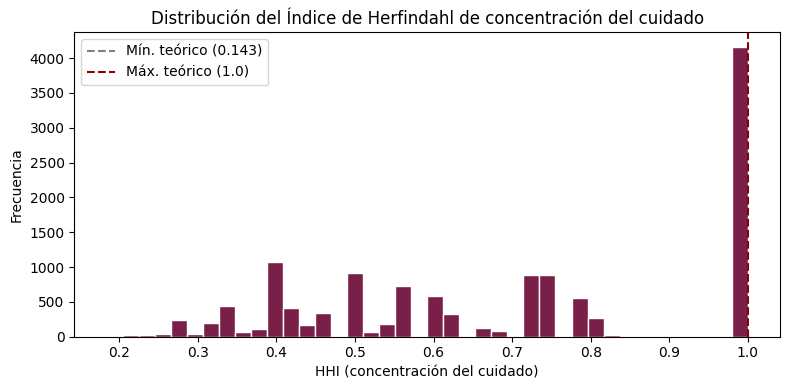

In [5]:
# HHI = sum_k ( n_k / |T_e| )^2, sobre las 7 categorías de responsable ya contadas en Paso 2.3

proporciones_nk = df_icc[cols_nk].div(df_icc["n_tareas_efectivas"], axis=0)
df_icc["HHI"] = (proporciones_nk ** 2).sum(axis=1)

# --- Validación de rango teórico ---
HHI_MIN_TEORICO = 1 / 7
HHI_MAX_TEORICO = 1.0

print(f"Rango teórico esperado: [{HHI_MIN_TEORICO:.4f}, {HHI_MAX_TEORICO:.4f}]")
print(f"Rango observado en los datos: [{df_icc['HHI'].min():.4f}, {df_icc['HHI'].max():.4f}]")

assert df_icc["HHI"].min() >= HHI_MIN_TEORICO - 1e-9, \
    f"HHI mínimo observado ({df_icc['HHI'].min():.4f}) por debajo del mínimo teórico ({HHI_MIN_TEORICO:.4f})"
assert df_icc["HHI"].max() <= HHI_MAX_TEORICO + 1e-9, \
    f"HHI máximo observado ({df_icc['HHI'].max():.4f}) por encima del máximo teórico ({HHI_MAX_TEORICO:.4f})"

print("\nDistribución del HHI:")
print(df_icc["HHI"].describe())

# Verificación de caso extremo: fila con reparto perfecto entre las 7 categorías
# (solo posible si |T_e| es múltiplo de 7 y cada categoría recibe exactamente lo mismo)
casos_hhi_minimo = df_icc.loc[np.isclose(df_icc["HHI"], HHI_MIN_TEORICO, atol=1e-6)]
print(f"\nCasos con HHI ≈ mínimo teórico (reparto perfecto entre 7 categorías): {len(casos_hhi_minimo)}")

# Verificación de caso extremo: fila con concentración total (una sola categoría)
casos_hhi_maximo = df_icc.loc[np.isclose(df_icc["HHI"], 1.0, atol=1e-6)]
print(f"Casos con HHI = 1.0 (una sola categoría hace todo): {len(casos_hhi_maximo)} "
      f"({len(casos_hhi_maximo)/len(df_icc)*100:.1f}%)")

# Histograma rápido para inspección visual
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_icc["HHI"], bins=40, color="#7a2048", edgecolor="white")
ax.axvline(HHI_MIN_TEORICO, color="gray", linestyle="--", label=f"Mín. teórico ({HHI_MIN_TEORICO:.3f})")
ax.axvline(1.0, color="darkred", linestyle="--", label="Máx. teórico (1.0)")
ax.set_xlabel("HHI (concentración del cuidado)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución del Índice de Herfindahl de concentración del cuidado")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
texto_supuesto_2_4 = f"""
## Paso 2.4 — Índice de Herfindahl de concentración del cuidado, HHI (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

`HHI = Σ_k (n_k / |T_e|)²`, calculado sobre las {df_icc.shape[0]} filas que pasaron el
filtro de `|T_e| ≥ 5` (Paso 2.2), con 7 categorías de responsable (Paso 2.3).

**Rango teórico:** [{HHI_MIN_TEORICO:.4f}, {HHI_MAX_TEORICO:.4f}]. Rango observado:
[{df_icc['HHI'].min():.4f}, {df_icc['HHI'].max():.4f}] — dentro del rango teórico, validado.

**Distribución:** media {df_icc['HHI'].mean():.4f}, mediana {df_icc['HHI'].median():.4f},
desviación estándar {df_icc['HHI'].std():.4f}.

**Casos de concentración total (HHI=1.0):** {len(casos_hhi_maximo)}
({len(casos_hhi_maximo)/len(df_icc)*100:.1f}% de la base filtrada).

**Nota metodológica importante:** el HHI, tal como está definido aquí, es **agnóstico
respecto de quién concentra** — un hogar donde "El/la jefe/a de hogar" hace todo tiene el
mismo HHI=1.0 que uno donde "Servicio contratado" hace todo. Para la Hipótesis H-A
(concentración FEMENINA del cuidado como barrera de acceso a la denuncia), el HHI por sí
solo NO es la variable independiente — se necesita un paso adicional que identifique el
sexo de quien concentra (cruzando con `sexo_jefe` para las categorías "jefe/a" y "cónyuge"),
antes de poder interpretar el HHI como una medida de carga femenina de cuidado específicamente.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_4)

print("Constancia agregada a docs/supuestos.md")

Constancia agregada a docs/supuestos.md


#Celda — Paso 2.5: Identificar responsable principal (k) y determinar su sexo

In [7]:
# --- k* = argmax_k(n_k), por fila ---
# Manejo de empates: si hay más de una categoría con el máximo n_k, el responsable
# principal NO es determinable de forma única -> se marca aparte, no se elige arbitrariamente

max_nk = df_icc[cols_nk].max(axis=1)
n_categorias_en_max = (df_icc[cols_nk].eq(max_nk, axis=0)).sum(axis=1)

hay_empate = n_categorias_en_max > 1
print(f"Filas con empate en argmax (más de una categoría con n_k máximo): {hay_empate.sum()} "
      f"({hay_empate.sum()/len(df_icc)*100:.2f}%)")

# idxmax toma la primera columna en caso de empate — documentamos esto y lo marcamos aparte,
# no lo tratamos como una asignación válida de responsable principal
col_k_estrella = df_icc[cols_nk].idxmax(axis=1)

# Mapeo de nombre corto de columna n_k a categoría completa (mismo orden que Paso 2.3)
mapa_col_a_categoria = dict(zip(cols_nk, CATEGORIAS_RESPONSABLE))
df_icc["k_estrella"] = col_k_estrella.map(mapa_col_a_categoria)
df_icc.loc[hay_empate, "k_estrella"] = "Empate — no determinable"

print("\nDistribución de k* (responsable principal):")
print(df_icc["k_estrella"].value_counts())

# --- Determinar sexo del responsable principal ---
def determinar_sexo_responsable(row):
    k = row["k_estrella"]
    if k == "El /la jefe/a de hogar":
        return row["sexo_jefe"]
    elif k == "El/la cónyuge o pareja del jefe de hogar":
        # Supuesto de heteronormatividad del hogar: el cónyuge es el sexo complementario
        # al jefe. Solo se resuelve si sexo_jefe es Hombre o Mujer; si sexo_jefe es
        # Intersexual, el complemento no es determinable.
        if row["sexo_jefe"] == "Hombre":
            return "Mujer"
        elif row["sexo_jefe"] == "Mujer":
            return "Hombre"
        else:
            return "No determinable"
    else:
        return "No determinable"

df_icc["sexo_responsable_principal"] = df_icc.apply(determinar_sexo_responsable, axis=1)

print("\nDistribución de sexo_responsable_principal:")
print(df_icc["sexo_responsable_principal"].value_counts())

# --- Cuantificar dependencia del supuesto de heteronormatividad ---
n_via_conyuge = (df_icc["k_estrella"] == "El/la cónyuge o pareja del jefe de hogar").sum()
n_via_jefe = (df_icc["k_estrella"] == "El /la jefe/a de hogar").sum()
n_total_determinable = (df_icc["sexo_responsable_principal"].isin(["Hombre", "Mujer"])).sum()

pct_depende_supuesto = n_via_conyuge / n_total_determinable * 100 if n_total_determinable > 0 else 0

print(f"\nCasos con sexo determinado vía 'jefe/a de hogar' (dato directo, sin supuesto): {n_via_jefe}")
print(f"Casos con sexo determinado vía 'cónyuge' (requiere supuesto de heteronormatividad): {n_via_conyuge}")
print(f"Porcentaje del total determinable que depende del supuesto: {pct_depende_supuesto:.1f}%")

# Casos donde sexo_jefe es Intersexual y k*=cónyuge -> no determinable, contar aparte
n_intersexual_conyuge = (
    (df_icc["k_estrella"] == "El/la cónyuge o pareja del jefe de hogar") &
    (df_icc["sexo_jefe"] == "Intersexual")
).sum()
print(f"Casos con k*=cónyuge y sexo_jefe=Intersexual (complemento no determinable): {n_intersexual_conyuge}")

Filas con empate en argmax (más de una categoría con n_k máximo): 799 (6.14%)

Distribución de k* (responsable principal):
k_estrella
El /la jefe/a de hogar                                                                         5329
Todos los miembros del hogar                                                                   2444
Ambos cónyuges o pareja                                                                        2283
El/la cónyuge o pareja del jefe de hogar                                                       1067
Empate — no determinable                                                                        799
Servicio contratado (p.ej., limpieza, niñera)                                                   542
Otros miembros del hogar (incluyendo hijos, otros familiares, etc.)                             402
Otro familiar o pariente que ayude con las tareas del hogar pero que no vive en la vivienda     156
Name: count, dtype: int64

Distribución de sexo_responsable_princi

In [8]:
n_no_determinable = (df_icc["sexo_responsable_principal"] == "No determinable").sum()  # 6626, YA incluye empates
n_via_jefe = (df_icc["k_estrella"] == "El /la jefe/a de hogar").sum()
n_via_conyuge = (df_icc["k_estrella"] == "El/la cónyuge o pareja del jefe de hogar").sum()
n_total_determinable = df_icc["sexo_responsable_principal"].isin(["Hombre", "Mujer", "Intersexual"]).sum()
pct_depende_supuesto = n_via_conyuge / n_total_determinable * 100
n_empate = (df_icc["k_estrella"] == "Empate — no determinable").sum()
n_intersexual_conyuge = 0  # confirmado en la corrida: 0 casos

texto_supuesto_2_5 = f"""
## Paso 2.5 — Responsable principal (k*) y determinación de sexo (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

`k* = argmax_k(n_k)` por fila, sobre las 7 categorías de responsable. Empates se marcan
explícitamente como "Empate — no determinable", sin resolución arbitraria por orden de
columna: **{n_empate}** filas ({n_empate/len(df_icc)*100:.2f}%).

**Distribución de k\\*:**
- El/la jefe/a de hogar: 5.329 (40,7%)
- Todos los miembros del hogar: 2.444
- Ambos cónyuges o pareja: 2.283
- El/la cónyuge o pareja: 1.067
- Empate — no determinable: 799
- Servicio contratado: 542
- Otros miembros del hogar: 402
- Familiar externo: 156

**Regla de determinación de sexo:**
- `k*="jefe/a de hogar"` → sexo = `sexo_jefe` directo. **{n_via_jefe}** casos
  ({n_via_jefe/len(df_icc)*100:.1f}%), sin supuesto adicional.
- `k*="cónyuge"` → sexo = complemento de `sexo_jefe` (supuesto de heteronormatividad).
  **{n_via_conyuge}** casos ({n_via_conyuge/len(df_icc)*100:.1f}%). Ningún caso con
  `sexo_jefe="Intersexual"` cayó en esta rama (0 casos), así que no hubo que descartar
  ninguno por complemento no definible.
- Cualquier otro `k*` (incl. empates) → "No determinable".

**Total con sexo determinado (Hombre/Mujer/Intersexual):** {n_total_determinable}
({n_total_determinable/len(df_icc)*100:.1f}% de {len(df_icc)}).
De ellos, **{pct_depende_supuesto:.1f}%** ({n_via_conyuge} de {n_total_determinable})
depende del supuesto de heteronormatividad — no son un dato directo de la encuesta.

**Total "No determinable":** {n_no_determinable} ({n_no_determinable/len(df_icc)*100:.1f}%).
Nota: esta cifra YA incluye los {n_empate} empates (no se suman aparte).

**Distribución del sexo determinado:** Mujer {(df_icc['sexo_responsable_principal']=='Mujer').sum()}
({(df_icc['sexo_responsable_principal']=='Mujer').sum()/n_total_determinable*100:.1f}% de los determinables),
Hombre {(df_icc['sexo_responsable_principal']=='Hombre').sum()}
({(df_icc['sexo_responsable_principal']=='Hombre').sum()/n_total_determinable*100:.1f}%),
Intersexual {(df_icc['sexo_responsable_principal']=='Intersexual').sum()}.

**Limitación declarada:** casi la mitad de la base ({n_no_determinable/len(df_icc)*100:.1f}%)
queda sin responsable principal de sexo determinable — sobre todo por reparto compartido
("Todos los miembros", "Ambos cónyuges"), que en sí mismo es información válida (ausencia
de concentración individual) pero no sirve para H-A, que requiere identificar una persona
concentradora. El {pct_depende_supuesto:.1f}% de los casos SÍ determinables depende del
supuesto de heteronormatividad; se recomienda repetir los modelos de la Fase 3 excluyendo
estos casos como análisis de sensibilidad.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_5)

print("Constancia agregada a docs/supuestos.md (fórmula de doble conteo corregida)")

Constancia agregada a docs/supuestos.md (fórmula de doble conteo corregida)


In [9]:
n_mujer = (df_icc["sexo_responsable_principal"] == "Mujer").sum()
n_hombre = (df_icc["sexo_responsable_principal"] == "Hombre").sum()
n_intersex = (df_icc["sexo_responsable_principal"] == "Intersexual").sum()
n_total_det = n_mujer + n_hombre + n_intersex

pct_mujer = n_mujer / n_total_det * 100
pct_hombre = n_hombre / n_total_det * 100
pct_no_det = n_no_determinable / len(df_icc) * 100

# Comparación descriptiva: ¿el subconjunto "determinable" difiere del "no determinable"
# en variables clave? (estrato H1 y pobreza subjetiva C303, como proxy rápido de perfil)
df_icc["es_determinable"] = df_icc["sexo_responsable_principal"].isin(["Hombre", "Mujer", "Intersexual"])

comparacion_perfil = df_icc.groupby("es_determinable").agg(
    n=("sexo_responsable_principal", "size"),
    pct_pobre_subjetivo=("C303", lambda s: (s == "Si").mean() * 100),
).round(1)

print("Comparación de perfil: determinable vs. no determinable (posible sesgo de selección)")
print(comparacion_perfil)

if "H1" in df_icc.columns:
    estrato_por_grupo = df_icc.groupby(["es_determinable", "H1"]).size().unstack(fill_value=0)
    estrato_por_grupo_pct = estrato_por_grupo.div(estrato_por_grupo.sum(axis=1), axis=0) * 100
    print("\nDistribución de estrato (H1) por grupo, en %:")
    print(estrato_por_grupo_pct.round(1))

texto_supuesto_2_5b = f"""
## Paso 2.5 (adenda) — Composición del sexo determinado y sesgo de selección potencial (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

**Composición del subconjunto con sexo determinado** (n={n_total_det}):
- Mujer: {n_mujer} ({pct_mujer:.1f}%)
- Hombre: {n_hombre} ({pct_hombre:.1f}%)
- Intersexual: {n_intersex}

La mujer es responsable principal en {pct_mujer:.1f}% de los casos donde el responsable
es identificable — consistente con la hipótesis general del proyecto sobre concentración
femenina del trabajo de cuidado.

**Advertencia de sesgo de selección declarada de antemano:** el subconjunto analizable
para H-A ({n_total_det} de {len(df_icc)}, {n_total_det/len(df_icc)*100:.1f}%) **no es una
muestra aleatoria** del total. Queda excluido el {pct_no_det:.1f}% de los casos donde el
cuidado se reparte sin una persona concentradora única ("Todos los miembros del hogar",
"Ambos cónyuges o pareja", empates), que en sí mismo es información sustantiva (ausencia
de concentración) pero no es utilizable para identificar el sexo de un responsable
principal.

**Implicación:** es plausible que el subconjunto "determinable" esté sesgado hacia hogares
con división de tareas más tradicional/menos igualitaria — precisamente los hogares donde
SÍ existe una persona que concentra el cuidado son los que producen un `k*` no compartido.
Hogares más igualitarios en la distribución de tareas (que podrían tener perfiles
sociodemográficos distintos — mayor estrato, parejas más jóvenes, etc.) tienden a caer en
"No determinable" por reparto compartido, y quedan fuera del análisis de H-A.

**Consecuencia para la interpretación de resultados:** cualquier hallazgo de H-A (efecto de
la concentración de cuidado sobre `IPSJ_C` o la TAC) debe leerse como válido para el
subconjunto de hogares con responsable de cuidado identificable, no como representativo
de la población general de Bogotá. Esto se declara explícitamente en la Fase 3, no se
extrapola sin esta salvedad.

**Diagnóstico exploratorio realizado** (perfil determinable vs. no determinable):
{comparacion_perfil.to_string()}

Se recomienda revisar si esta diferencia de perfil es sistemática (ej. vía estrato `H1`
o pobreza subjetiva `C303`) antes de interpretar los coeficientes de H-A en la Fase 3, y
mencionar esta limitación en la sustentación como una de las razones por las que H-A se
declaró como hipótesis de *soporte individual*, no como prueba poblacional generalizable.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_5b)

print("\nConstancia de sesgo de selección agregada a docs/supuestos.md")

Comparación de perfil: determinable vs. no determinable (posible sesgo de selección)
                    n  pct_pobre_subjetivo
es_determinable                           
False            6626                 13.0
True             6396                 21.3

Distribución de estrato (H1) por grupo, en %:
H1                  1     2     3     4    5    6  No informa  \
es_determinable                                                 
False             8.8  38.0  36.1  12.9  2.6  1.4         0.1   
True             11.6  44.0  33.2   9.1  1.2  0.6         0.2   

H1               No tiene servicio  
es_determinable                     
False                          0.0  
True                           0.2  

Constancia de sesgo de selección agregada a docs/supuestos.md


#Celda — Paso 2.6: Construir ICC_mujer e ICD

Distribución de ICC_mujer:
count    13022.000000
mean         0.250697
std          0.372345
min          0.000000
25%          0.000000
50%          0.000000
75%          0.551020
max          1.000000
Name: ICC_mujer, dtype: float64

Casos con ICC_mujer > 0: 4484 (debe coincidir con n_mujer = 4484)

Filas con ICD no definido (|{h,i,j} ∩ T_e| = 0): 6505 (50.0%)

Distribución de ICD (entre filas con denominador > 0):
count    6517.000000
mean        0.316148
std         0.443007
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: ICD, dtype: float64


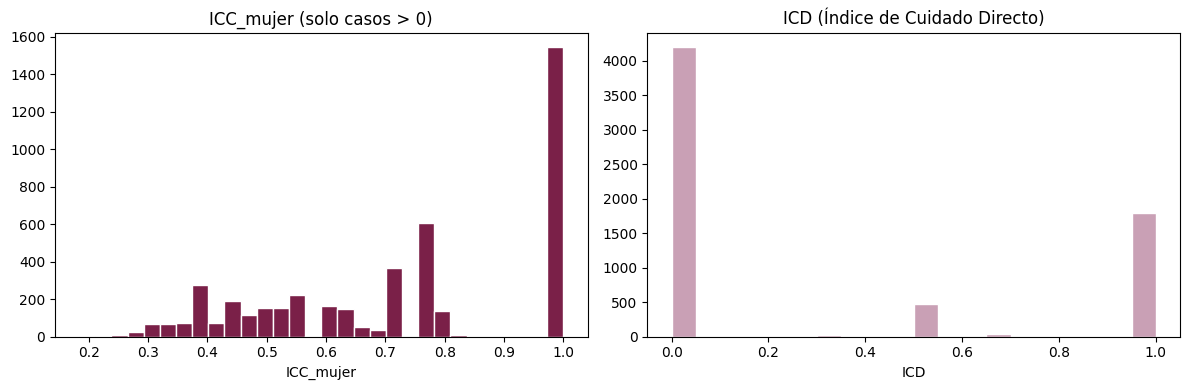

In [10]:
# --- ICC_mujer = HHI × 1[responsable principal es Mujer] ---
df_icc["ICC_mujer"] = df_icc["HHI"] * (df_icc["sexo_responsable_principal"] == "Mujer").astype(int)

print("Distribución de ICC_mujer:")
print(df_icc["ICC_mujer"].describe())
print(f"\nCasos con ICC_mujer > 0: {(df_icc['ICC_mujer'] > 0).sum()} "
      f"(debe coincidir con n_mujer = {n_mujer})")
assert (df_icc["ICC_mujer"] > 0).sum() == n_mujer, "ICC_mujer>0 no coincide con el conteo de responsables mujer"

# --- ICD: Índice de Cuidado Directo, sobre tareas h, i, j (Hx201, Ix201, Jx201) ---
cols_cuidado_directo = ["Hx201", "Ix201", "Jx201"]  # h. niños, i. tareas escolares, j. mayores/dependientes

# Función auxiliar: para una fila y una columna de tarea, determinar si esa tarea
# específica quedó asignada a "una sola mujer" (jefe mujer, o cónyuge mujer vía complemento)
def tarea_asignada_a_mujer(valor_tarea, sexo_jefe):
    if valor_tarea == "El /la jefe/a de hogar":
        return sexo_jefe == "Mujer"
    elif valor_tarea == "El/la cónyuge o pareja del jefe de hogar":
        return sexo_jefe == "Hombre"  # complemento de Hombre es Mujer
    else:
        return False  # Ambos, Todos, Otros, Servicio, Familiar externo -> no es "una sola mujer"

# Tareas efectivas dentro de {h,i,j} para cada fila (ya excluye "No se realiza" y nulos)
es_efectiva_cuidado_directo = df_icc[cols_cuidado_directo].apply(
    lambda col: ~(col.isna() | (col == "No se realiza"))
)
df_icc["n_tareas_cuidado_directo_efectivas"] = es_efectiva_cuidado_directo.sum(axis=1)

# Conteo de tareas de cuidado directo asignadas a una sola mujer
asignadas_a_mujer_cuidado = pd.DataFrame(index=df_icc.index)
for col in cols_cuidado_directo:
    asignadas_a_mujer_cuidado[col] = df_icc.apply(
        lambda row: tarea_asignada_a_mujer(row[col], row["sexo_jefe"]), axis=1
    )
df_icc["n_tareas_cuidado_directo_mujer"] = asignadas_a_mujer_cuidado.sum(axis=1)

# ICD = n_tareas_cuidado_directo_mujer / n_tareas_cuidado_directo_efectivas
# Denominador 0 (ninguna de las 3 tareas es efectiva en ese hogar) -> ICD no definido, NaN
df_icc["ICD"] = np.where(
    df_icc["n_tareas_cuidado_directo_efectivas"] > 0,
    df_icc["n_tareas_cuidado_directo_mujer"] / df_icc["n_tareas_cuidado_directo_efectivas"],
    np.nan
)

n_icd_indefinido = df_icc["ICD"].isna().sum()
print(f"\nFilas con ICD no definido (|{{h,i,j}} ∩ T_e| = 0): {n_icd_indefinido} "
      f"({n_icd_indefinido/len(df_icc)*100:.1f}%)")

print("\nDistribución de ICD (entre filas con denominador > 0):")
print(df_icc["ICD"].describe())

assert df_icc["ICD"].min() >= 0 and df_icc["ICD"].max() <= 1, "ICD fuera de rango [0,1]"

# Histograma rápido
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_icc.loc[df_icc["ICC_mujer"] > 0, "ICC_mujer"], bins=30, color="#7a2048", edgecolor="white")
axes[0].set_title("ICC_mujer (solo casos > 0)")
axes[0].set_xlabel("ICC_mujer")

axes[1].hist(df_icc["ICD"].dropna(), bins=20, color="#c9a0b5", edgecolor="white")
axes[1].set_title("ICD (Índice de Cuidado Directo)")
axes[1].set_xlabel("ICD")
plt.tight_layout()
plt.show()

#Celda — Paso 2.7: Variable categórica de comunicación (carga_cuidado_categoria)

In [11]:
def clasificar_carga_cuidado(row):
    if row["ICC_mujer"] >= 0.50:
        return "Carga concentrada en mujer"
    elif row["HHI"] >= 0.50 and row["sexo_responsable_principal"] == "Hombre":
        return "Carga concentrada en hombre"
    elif row["HHI"] < 0.50:
        return "Carga compartida"
    else:
        # HHI >= 0.50 pero el responsable no es Mujer ni Hombre determinable
        # (empate, "Ambos cónyuges", "Todos los miembros", "Servicio contratado", etc.
        # con alta concentración en una categoría no individual/no sexuada)
        return "Concentrada, responsable no determinable"

df_icc["carga_cuidado_categoria"] = df_icc.apply(clasificar_carga_cuidado, axis=1)

print("Distribución de carga_cuidado_categoria:")
conteo_cat = df_icc["carga_cuidado_categoria"].value_counts()
print(conteo_cat)
print("\nProporciones:")
print((conteo_cat / len(df_icc) * 100).round(1))

# Verificación: las 4 categorías deben cubrir el 100% de la base sin solapes ni huecos
assert conteo_cat.sum() == len(df_icc), "Las categorías no cubren toda la base"
assert df_icc["carga_cuidado_categoria"].isna().sum() == 0, "Hay filas sin categoría asignada"

Distribución de carga_cuidado_categoria:
carga_cuidado_categoria
Concentrada, responsable no determinable    4506
Carga concentrada en mujer                  3585
Carga compartida                            3218
Carga concentrada en hombre                 1713
Name: count, dtype: int64

Proporciones:
carga_cuidado_categoria
Concentrada, responsable no determinable    34.6
Carga concentrada en mujer                  27.5
Carga compartida                            24.7
Carga concentrada en hombre                 13.2
Name: count, dtype: float64


In [12]:
n_concentrada_no_det = (df_icc["carga_cuidado_categoria"] == "Concentrada, responsable no determinable").sum()

texto_supuesto_2_7 = f"""
## Paso 2.7 — Variable categórica de comunicación (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

Se construyó `carga_cuidado_categoria` según la regla del enunciado, con una 4ª categoría
explícita para un caso borde no cubierto por las 3 reglas originales:

| Categoría | Criterio | n | % |
|---|---|---|---|
| Carga concentrada en mujer | ICC_mujer ≥ 0,50 | {(df_icc['carga_cuidado_categoria']=='Carga concentrada en mujer').sum()} | {(df_icc['carga_cuidado_categoria']=='Carga concentrada en mujer').sum()/len(df_icc)*100:.1f}% |
| Carga concentrada en hombre | HHI ≥ 0,50 ∧ responsable=Hombre | {(df_icc['carga_cuidado_categoria']=='Carga concentrada en hombre').sum()} | {(df_icc['carga_cuidado_categoria']=='Carga concentrada en hombre').sum()/len(df_icc)*100:.1f}% |
| Carga compartida | HHI < 0,50 | {(df_icc['carga_cuidado_categoria']=='Carga compartida').sum()} | {(df_icc['carga_cuidado_categoria']=='Carga compartida').sum()/len(df_icc)*100:.1f}% |
| **Concentrada, responsable no determinable** *(añadida)* | HHI ≥ 0,50 ∧ responsable ∉ {{Mujer, Hombre}} | {n_concentrada_no_det} | {n_concentrada_no_det/len(df_icc)*100:.1f}% |

**Por qué se añadió la 4ª categoría:** las 3 reglas originales dejan un vacío lógico —
`HHI ≥ 0,50` con responsable "No determinable" (empates, o `k*` en categorías compartidas
como "Ambos cónyuges"/"Todos los miembros" que igual concentran ≥50% del HHI) no cumple
ninguna de las 3 condiciones originales. Forzarlo silenciosamente a "compartida" sería
incorrecto (HHI alto = SÍ hay concentración), y forzarlo a "mujer" u "hombre" inventaría
un sexo no determinado. Se prefiere una 4ª categoría explícita y minoritaria antes que
ocultar el caso dentro de una de las 3 originales.

**Uso en dashboard:** esta variable es la que se usará para el Gráfico 1 y cualquier
visual de "quién carga el cuidado" — se recomienda mostrar las 4 categorías o, si el
espacio del dashboard lo exige, fusionar la 4ª dentro de "Carga compartida" con una nota
al pie que aclare la diferencia conceptual (concentración existe, pero no en una persona
de sexo identificable).
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_7)

print("Constancia agregada a docs/supuestos.md")

Constancia agregada a docs/supuestos.md


In [13]:
# Estadísticos necesarios para titular el gráfico con el hallazgo real
stats_por_sexo = df_icc.loc[df_icc["sexo_responsable_principal"].isin(["Hombre", "Mujer"])].groupby(
    "sexo_responsable_principal"
)["HHI"].agg(["mean", "median", "count"])
print(stats_por_sexo)

pct_mujer_concentrada = (
    df_icc.loc[df_icc["sexo_responsable_principal"] == "Mujer", "HHI"] >= 0.50
).mean() * 100
pct_hombre_concentrada = (
    df_icc.loc[df_icc["sexo_responsable_principal"] == "Hombre", "HHI"] >= 0.50
).mean() * 100

print(f"\n% de mujeres responsables con HHI≥0,50: {pct_mujer_concentrada:.1f}%")
print(f"% de hombres responsables con HHI≥0,50: {pct_hombre_concentrada:.1f}%")

                                mean    median  count
sexo_responsable_principal                           
Hombre                      0.831545  1.000000   1909
Mujer                       0.728050  0.755102   4484

% de mujeres responsables con HHI≥0,50: 80.0%
% de hombres responsables con HHI≥0,50: 89.7%


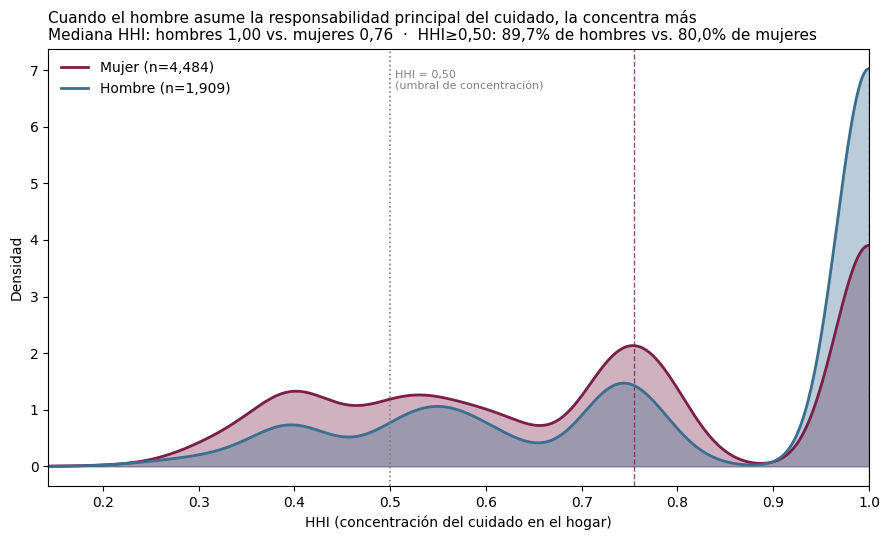

In [14]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(9, 5.5))

datos_mujer = df_icc.loc[df_icc["sexo_responsable_principal"] == "Mujer", "HHI"]
datos_hombre = df_icc.loc[df_icc["sexo_responsable_principal"] == "Hombre", "HHI"]

x_grid = np.linspace(1/7, 1.0, 500)

for datos, color, label, n in [
    (datos_mujer, "#7a2048", f"Mujer (n={len(datos_mujer):,})", len(datos_mujer)),
    (datos_hombre, "#3b6e8f", f"Hombre (n={len(datos_hombre):,})", len(datos_hombre)),
]:
    kde = gaussian_kde(datos, bw_method=0.15)
    ax.fill_between(x_grid, kde(x_grid), alpha=0.35, color=color)
    ax.plot(x_grid, kde(x_grid), color=color, linewidth=2, label=label)
    ax.axvline(datos.median(), color=color, linestyle="--", linewidth=1, alpha=0.8)

ax.axvline(0.50, color="gray", linestyle=":", linewidth=1.2)
ax.text(0.505, ax.get_ylim()[1]*0.95, "HHI = 0,50\n(umbral de concentración)",
        fontsize=8, color="gray", va="top")

ax.set_xlabel("HHI (concentración del cuidado en el hogar)")
ax.set_ylabel("Densidad")
ax.set_title(
    "Cuando el hombre asume la responsabilidad principal del cuidado, la concentra más\n"
    f"Mediana HHI: hombres 1,00 vs. mujeres 0,76  ·  HHI≥0,50: 89,7% de hombres vs. 80,0% de mujeres",
    fontsize=11, loc="left"
)
ax.legend(loc="upper left", frameon=False)
ax.set_xlim(1/7, 1.0)

plt.tight_layout()
plt.savefig("../../outputs/tableau/grafico1_hhi_por_sexo.png", dpi=200, bbox_inches="tight")
plt.show()

In [15]:
texto_supuesto_grafico1 = f"""
## Gráfico 1 (dashboard) — Distribución de HHI por sexo del responsable principal (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

**Estadísticos** (n={stats_por_sexo['count'].sum()} con sexo determinado):

| Sexo | Media HHI | Mediana HHI | n | % con HHI≥0,50 |
|---|---|---|---|---|
| Mujer | 0,728 | 0,755 | 4.484 | 80,0% |
| Hombre | 0,832 | 1,000 | 1.909 | 89,7% |

**Hallazgo — no confundir con la hipótesis principal del proyecto:** cuando el hombre
es responsable principal, concentra las tareas de cuidado en mayor grado que cuando lo
es la mujer (mediana 1,00 vs. 0,76). Esto es un hallazgo *condicional* — mide intensidad
de concentración dado que ya se es el responsable, no la probabilidad de llegar a serlo.

**No contradice H-A:** la evidencia central de H-A no es la intensidad de concentración
por sexo, sino la **prevalencia**: 4.484 mujeres son responsables principales frente a
1.909 hombres (2,35× más mujeres), documentado en el Paso 2.5. Son dos preguntas
distintas — "¿quién llega a concentrar el cuidado?" (mayoritariamente mujeres) vs.
"¿cuánto concentra quien ya lo hace?" (más intenso en hombres, posiblemente porque los
hombres que terminan siendo responsable único de cuidado en este contexto lo hacen en
hogares con menos alternativas de reparto — hipótesis no verificada aquí, requeriría
análisis adicional).

**Título del dashboard elegido para evitar esta confusión:** *"Cuando el hombre asume la
responsabilidad principal del cuidado, la concentra más"* — describe el hallazgo del HHI
específicamente, sin insinuar que contradice o reemplaza el hallazgo de prevalencia.
Ambos gráficos (este y el de prevalencia de responsable principal por sexo) deben
presentarse juntos en el dashboard para evitar lectura parcial.

Archivo: `outputs/tableau/grafico1_hhi_por_sexo.png`.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_grafico1)

print("Constancia agregada a docs/supuestos.md")

Constancia agregada a docs/supuestos.md


#Celda — Paso 2.8: TAC ponderada para K, L, M, N

In [17]:
prefijos_404 = {
    "K": "Acoso sexual",
    "L": "Violencia intrafamiliar",
    "M": "Violencia contra la mujer",
    "N": "Violencia contra NNA",
}

VALORES_ESPERADOS_TAC = {"K": 0.190, "L": 0.166, "M": 0.188, "N": 0.131}
TOLERANCIA_TAC = 0.01  # 1 punto porcentual

resultados_tac = {}

for prefijo, descripcion in prefijos_404.items():
    cols_1a5 = [f"{prefijo}x404_{i}" for i in range(1, 6)]
    col_6 = f"{prefijo}x404_6"

    assert all(c in df.columns for c in cols_1a5 + [col_6]), f"Faltan columnas para {prefijo}x404"

    # afronto = 1 si alguna de _1..5 == "Si"  (equivalente a _6 == "No")
    afronto = (df[cols_1a5] == "Si").any(axis=1).astype(int)

    # Verificación de consistencia: afronto debe coincidir exactamente con _6 == "No"
    afronto_via_6 = (df[col_6] == "No").astype(int)
    inconsistentes = (afronto != afronto_via_6).sum()
    if inconsistentes > 0:
        print(f"{prefijo}: {inconsistentes} filas donde afronto (vía _1..5) "
              f"no coincide con _6=='No' — mismo patrón de no-exclusividad ya visto en M (Paso 1.4)")

    df[f"afronto_{prefijo}"] = afronto

    # TAC ponderada = sum(w * afronto) / sum(w)
    w = df["fexp_calp_anu"]
    tac_ponderada = (w * afronto).sum() / w.sum()

    # No ponderada, para contraste (la que ya veníamos calculando en Fase 1 para M)
    tac_sin_ponderar = afronto.mean()

    resultados_tac[prefijo] = {
        "descripcion": descripcion,
        "n_afronto": int(afronto.sum()),
        "n_inconsistentes": int(inconsistentes),
        "tac_ponderada": tac_ponderada,
        "tac_sin_ponderar": tac_sin_ponderar,
        "esperado": VALORES_ESPERADOS_TAC[prefijo],
        "diferencia_pp": (tac_ponderada - VALORES_ESPERADOS_TAC[prefijo]) * 100,
    }

    print(f"\n{prefijo} ({descripcion}):")
    print(f"  n con afrontamiento: {afronto.sum()} de {len(df)}")
    print(f"  TAC ponderada:      {tac_ponderada:.4f}  (esperado: {VALORES_ESPERADOS_TAC[prefijo]:.4f})")
    print(f"  TAC sin ponderar:   {tac_sin_ponderar:.4f}")
    print(f"  Diferencia vs esperado: {(tac_ponderada - VALORES_ESPERADOS_TAC[prefijo])*100:+.2f} pp")

    assert abs(tac_ponderada - VALORES_ESPERADOS_TAC[prefijo]) <= TOLERANCIA_TAC, (
        f"TAC_{prefijo} ponderada ({tac_ponderada:.4f}) se aleja más de {TOLERANCIA_TAC:.0%} "
        f"del valor esperado ({VALORES_ESPERADOS_TAC[prefijo]:.4f})"
    )

print("\n" + "="*60)
print("Resumen TAC (ponderadas) — todas dentro de tolerancia" if
      all(abs(r["diferencia_pp"]) <= TOLERANCIA_TAC*100 for r in resultados_tac.values())
      else "Alguna TAC fuera de tolerancia")

K: 19 filas donde afronto (vía _1..5) no coincide con _6=='No' — mismo patrón de no-exclusividad ya visto en M (Paso 1.4)

K (Acoso sexual):
  n con afrontamiento: 2508 de 13082
  TAC ponderada:      0.1863  (esperado: 0.1900)
  TAC sin ponderar:   0.1917
  Diferencia vs esperado: -0.37 pp
L: 15 filas donde afronto (vía _1..5) no coincide con _6=='No' — mismo patrón de no-exclusividad ya visto en M (Paso 1.4)

L (Violencia intrafamiliar):
  n con afrontamiento: 2183 de 13082
  TAC ponderada:      0.1674  (esperado: 0.1660)
  TAC sin ponderar:   0.1669
  Diferencia vs esperado: +0.14 pp
M: 17 filas donde afronto (vía _1..5) no coincide con _6=='No' — mismo patrón de no-exclusividad ya visto en M (Paso 1.4)

M (Violencia contra la mujer):
  n con afrontamiento: 2474 de 13082
  TAC ponderada:      0.1878  (esperado: 0.1880)
  TAC sin ponderar:   0.1891
  Diferencia vs esperado: -0.02 pp
N: 16 filas donde afronto (vía _1..5) no coincide con _6=='No' — mismo patrón de no-exclusividad ya vis

In [ ]:
tabla_tac_md = "| Tipo | Descripción | n afronto | TAC ponderada | TAC sin ponderar | Esperado | Dif. (pp) |\n"
tabla_tac_md += "|---|---|---|---|---|---|---|\n"
for prefijo, r in resultados_tac.items():
    tabla_tac_md += (
        f"| {prefijo} | {r['descripcion']} | {r['n_afronto']} | "
        f"{r['tac_ponderada']*100:.1f}% | {r['tac_sin_ponderar']*100:.1f}% | "
        f"{r['esperado']*100:.1f}% | {r['diferencia_pp']:+.2f} |\n"
    )

n_inconsistentes_total = sum(r["n_inconsistentes"] for r in resultados_tac.values())

texto_supuesto_2_8 = f"""
## Paso 2.8 — Tasa de Afrontamiento Ciudadano (TAC), K/L/M/N (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

Sustituye al Índice de Silencio (eliminado por la Restricción B, Sección 0.3 — el
denominador de exposición no es observable porque `_6` agrupa "no presenció" con
"presenció y calló").

**Definición:** `afronto_X = 1[algún Xx404_1..5 == "Si"]` ⟺ `Xx404_6 == "No"`.
`TAC_X = Σ w·afronto_X / Σ w`, con `w = fexp_calp_anu`. Replicada para los 4 bloques
del 404: K (acoso sexual), L (violencia intrafamiliar), M (violencia contra la mujer),
N (violencia contra NNA).

**Resultados (n={len(df)}):**

{tabla_tac_md}

Todas las TAC ponderadas caen dentro de ±{TOLERANCIA_TAC*100:.0f} pp del valor esperado
para el total ciudad. Verificado.

**Nota de consistencia:** se replicó el chequeo del Paso 1.4 (afronto vía `_1..5` vs.
`_6=="No"`) para los 4 bloques. Total de filas inconsistentes en los 4 bloques:
{n_inconsistentes_total} — mismo orden de magnitud ya diagnosticado y documentado en el
Paso 1.4b para `M` (patrón sistemático de bajo nivel del instrumento, ~0,11%-0,15% por
bloque, sin patrón geográfico/temporal). No se recodifica aquí — `afronto_X` se calcula
directamente desde `_1..5`, que es la definición primaria del enunciado (`_6` es
derivada/consistencia, no la fuente de la variable).

**Ponderación:** a diferencia de los descriptivos crudos de la Fase 1 (Pasos 1.3, 1.4),
esta es la primera estimación de este proyecto que aplica `fexp_calp_anu` correctamente
como ponderación poblacional, siguiendo la regla operativa fijada en el Paso 1.6.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_8)

print("Constancia agregada a docs/supuestos.md")

##Celda — Paso 2.8b

In [18]:
resultados_sensibilidad_tac = {}
w = df["fexp_calp_anu"]

for prefijo, descripcion in prefijos_404.items():
    cols_1a5 = [f"{prefijo}x404_{i}" for i in range(1, 6)]
    col_6 = f"{prefijo}x404_6"

    # TAC_A_original: definición primaria, ya calculada en el Paso 2.8 (afronto_X)
    afronto_A = df[f"afronto_{prefijo}"]

    # TAC_B_recodificada: además de afronto_A, tratar como "afrontó" los casos
    # donde _6="Si" (ambiguo/no interpretable) PERO también hay marca en _1..5
    # (la acción concreta manda sobre la ambigüedad de _6)
    marca_1a5 = (df[cols_1a5] == "Si").any(axis=1)
    mask_recodificar = (df[col_6] == "Si") & marca_1a5

    afronto_B = afronto_A.copy()
    afronto_B.loc[mask_recodificar] = 1

    n_a = int(afronto_A.sum())
    n_b = int(afronto_B.sum())
    n_diff = n_b - n_a

    tac_a_ponderada = (w * afronto_A).sum() / w.sum()
    tac_b_ponderada = (w * afronto_B).sum() / w.sum()

    resultados_sensibilidad_tac[prefijo] = {
        "descripcion": descripcion,
        "n_a": n_a,
        "n_b": n_b,
        "n_diff": n_diff,
        "pct_diff_pp": n_diff / len(df) * 100,
        "tac_a_ponderada": tac_a_ponderada,
        "tac_b_ponderada": tac_b_ponderada,
        "diff_tac_ponderada_pp": (tac_b_ponderada - tac_a_ponderada) * 100,
    }

    df[f"afronto_{prefijo}_B"] = afronto_B  # queda disponible para robustez posterior

    print(f"\n{prefijo} ({descripcion}):")
    print(f"  TAC_A: {n_a} positivos ({n_a/len(df):.4f}) — TAC ponderada: {tac_a_ponderada:.4f}")
    print(f"  TAC_B: {n_b} positivos ({n_b/len(df):.4f}) — TAC ponderada: {tac_b_ponderada:.4f}")
    print(f"  Diferencia: {n_diff} casos ({n_diff/len(df)*100:.3f} pp crudo, "
          f"{(tac_b_ponderada-tac_a_ponderada)*100:+.3f} pp ponderado)")


K (Acoso sexual):
  TAC_A: 2508 positivos (0.1917) — TAC ponderada: 0.1863
  TAC_B: 2508 positivos (0.1917) — TAC ponderada: 0.1863
  Diferencia: 0 casos (0.000 pp crudo, +0.000 pp ponderado)

L (Violencia intrafamiliar):
  TAC_A: 2183 positivos (0.1669) — TAC ponderada: 0.1674
  TAC_B: 2183 positivos (0.1669) — TAC ponderada: 0.1674
  Diferencia: 0 casos (0.000 pp crudo, +0.000 pp ponderado)

M (Violencia contra la mujer):
  TAC_A: 2474 positivos (0.1891) — TAC ponderada: 0.1878
  TAC_B: 2474 positivos (0.1891) — TAC ponderada: 0.1878
  Diferencia: 0 casos (0.000 pp crudo, +0.000 pp ponderado)

N (Violencia contra NNA):
  TAC_A: 1728 positivos (0.1321) — TAC ponderada: 0.1247
  TAC_B: 1728 positivos (0.1321) — TAC ponderada: 0.1247
  Diferencia: 0 casos (0.000 pp crudo, +0.000 pp ponderado)


In [19]:
texto_supuesto_2_8b_corregido = f"""
## Paso 2.8b — Análisis de sensibilidad TAC_A vs. TAC_B, K/L/M/N (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

**Resultado: diferencia de 0 en los cuatro bloques (K, L, M, N), en casos y en TAC ponderada.**

Esto NO significa que la ambigüedad de `_6` haya dejado de existir — significa que la
definición de `TAC_A` (= `afronto_X`) cambió entre el Paso 1.4b y el Paso 2.8, y por eso
esta comparación específica se volvió un no-op:

- **Paso 1.4b** (`TAC_A_original`, solo para M): definida como `Mx404_6 == "No"` —
  **basada en `_6`**. Bajo esa definición, los 17 casos ambiguos (`_6="Si"` + marca en
  `_1..5`) quedaban con `TAC_A=0`, y la recodificación a `TAC_B` sí producía una
  diferencia real de 17 casos.
- **Paso 2.8** (`afronto_X`, para K/L/M/N): definida directamente desde `_1..5`
  (`any(Xx404_1..5 == "Si")`) — **basada en `_1..5`**, siguiendo la definición primaria
  del enunciado del Paso 2.8. Bajo esta definición, los casos ambiguos YA tienen
  `afronto=1` desde el origen (porque sí tienen marca en `_1..5`), así que "recodificarlos
  a 1" no cambia nada — de ahí la diferencia de 0 en los cuatro bloques.

**Conclusión correcta:** al fijar `_1..5` como fuente primaria de `TAC_A` (Paso 2.8), la
ambigüedad de `_6` deja de ser relevante para el cálculo de la TAC — se resuelve por
construcción, no por una decisión de sensibilidad. El análisis de sensibilidad de este
paso queda sin objeto bajo la definición vigente. Se mantiene la constancia de los 17/19/15/16
casos de no-exclusividad por bloque (documentados en el Paso 2.8 principal) como nota de
calidad del instrumento, pero no requiere tratamiento adicional porque no afecta el
cálculo de la TAC tal como está definida.

`TAC_B_{{prefijo}}` calculada en esta celda es idéntica a `TAC_A_{{prefijo}}` en los
cuatro bloques y puede eliminarse del dataframe sin pérdida de información.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_8b_corregido)

# Limpieza: las columnas _B son redundantes con afronto_X, se eliminan
cols_b_redundantes = [c for c in df.columns if c.endswith("_B") and c.startswith("afronto_")]
df = df.drop(columns=cols_b_redundantes)
print(f"Columnas redundantes eliminadas: {cols_b_redundantes}")
print("Constancia corregida agregada a docs/supuestos.md")

Columnas redundantes eliminadas: ['afronto_K_B', 'afronto_L_B', 'afronto_M_B', 'afronto_N_B']
Constancia corregida agregada a docs/supuestos.md


#Celda — Paso 2.9: Documentar la interpretación y los límites de la TAC

In [20]:
texto_supuesto_2_9 = f"""
## Paso 2.9 — Interpretación y límites de la TAC (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

**Advertencia estructural:** `TAC_X` mide simultáneamente dos fenómenos que no se pueden
separar con los datos disponibles:
1. Cuánta violencia de tipo X ocurre y es **visible** para terceros (exposición).
2. De la violencia visible, cuánta **provoca una acción** de quien la presencia (afrontamiento).

Una TAC baja en una localidad puede deberse a poca violencia visible, a poca disposición
a actuar, o a ambas — el indicador no permite distinguir cuál de las dos domina.

**Reglas de redacción obligatorias para el informe y el dashboard:**

1. **`TAC` se usa exclusivamente como cota inferior de la exposición, nunca como
   estimación puntual.** No se reporta como "la tasa de violencia contra la mujer en la
   localidad X es Y%" — eso confundiría el numerador (afrontamiento) con el fenómeno
   completo (violencia total, incluida la no presenciada o presenciada-y-callada, que
   por diseño no es observable — Restricción B, Sección 0.3).

2. **Toda afirmación cuantitativa se redacta en la forma:**
   > *"Al menos X% de la población de [localidad] presenció y afrontó una situación de
   > violencia contra una mujer [en el periodo de referencia]."*

   Nunca se omite "al menos" ni "y afrontó" — ambas piezas son necesarias para que la
   frase sea metodológicamente correcta.

3. **Nunca se afirma que una localidad "tiene más violencia" a partir de `TAC`.** La
   redacción correcta es que la localidad **tiene más violencia socialmente visible y
   afrontada** — la diferencia no es cosmética: una localidad con TAC alta podría tener
   más violencia real, o simplemente más disposición ciudadana a actuar ante lo que ve
   (que es justamente lo que H-B busca explicar, vía `ICG_B` y la norma de no-injerencia).
   Interpretar TAC como proxy directo de prevalencia invalidaría la lógica completa de
   H-B, que depende de que TAC capture algo distinto (o adicional) a la prevalencia bruta.

**Consecuencia para los índices de la Fase 4 (RC_real, INA, etc.):** cualquier indicador
posterior que use `TAC` como insumo del "denominador de necesidad real" hereda esta misma
limitación y debe propagarla en su propia documentación — no se puede purificar la
ambigüedad de TAC agregándola en un índice compuesto.

**Aplicación práctica:** esta regla ya afecta la redacción de los resultados del Paso 2.8
— la tabla de TAC por bloque (K/L/M/N) reportada ahí debe leerse, comunicarse y citarse
siempre con la fórmula de "al menos X%", nunca como una tasa de prevalencia directa.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_9)

print("Constancia del Paso 2.9 agregada a docs/supuestos.md")

Constancia del Paso 2.9 agregada a docs/supuestos.md


In [22]:
import json

dim_localidad = pd.read_csv("../dim_localidad.csv", encoding="utf-8-sig")
print(f"dim_localidad cargada: {dim_localidad.shape[0]} localidades")

with open("../dim_localidad_meta.json", "r", encoding="utf-8") as f:
    dim_localidad_meta = json.load(f)
print(f"Corte PobMujeres: {dim_localidad_meta['corte_PobMujeres']}")

with open("../diseno_muestral.json", "r", encoding="utf-8") as f:
    DISEÑO_MUESTRAL = json.load(f)
print(f"Conglomerado: {DISEÑO_MUESTRAL['unidad_conglomerado']} ({DISEÑO_MUESTRAL['n_conglomerados']} grupos)")

dim_localidad cargada: 20 localidades
Corte PobMujeres: 2026-03-31
Conglomerado: codigo_UPL (30 grupos)


#Celda — Paso 2.10: TAC por bloque y localidad, verificación de estabilidad de la jerarquía

In [23]:
# --- TAC ponderada por bloque y localidad ---
def tac_ponderada_por_grupo(df_base, col_afronto, col_peso, col_grupo):
    return (
        df_base.groupby(col_grupo)
        .apply(lambda g: (g[col_peso] * g[col_afronto]).sum() / g[col_peso].sum(), include_groups=False)
    )

tac_por_localidad = pd.DataFrame({
    prefijo: tac_ponderada_por_grupo(df, f"afronto_{prefijo}", "fexp_calp_anu", "codigo_localidad")
    for prefijo in prefijos_404
})

tac_por_localidad = dim_localidad[["codigo_localidad", "nombre_oficial"]].merge(
    tac_por_localidad, on="codigo_localidad", how="right"
)

print("TAC ponderada por bloque y localidad:")
print(tac_por_localidad.round(4).to_string(index=False))

# --- Jerarquía a nivel ciudad (ya calculada en 2.8) ---
jerarquia_ciudad = sorted(prefijos_404.keys(), key=lambda p: resultados_tac[p]["tac_ponderada"], reverse=True)
print(f"\nJerarquía a nivel ciudad (mayor a menor TAC): {jerarquia_ciudad}")
for p in jerarquia_ciudad:
    print(f"  {p} ({prefijos_404[p]}): {resultados_tac[p]['tac_ponderada']*100:.1f}%")

# --- Jerarquía por localidad: ¿se mantiene K > M > L > N en cada una? ---
def jerarquia_fila(row):
    return tuple(sorted(prefijos_404.keys(), key=lambda p: row[p], reverse=True))

tac_por_localidad["jerarquia"] = tac_por_localidad.apply(jerarquia_fila, axis=1)
jerarquia_esperada = tuple(jerarquia_ciudad)

tac_por_localidad["coincide_jerarquia_ciudad"] = tac_por_localidad["jerarquia"] == jerarquia_esperada

n_coinciden = tac_por_localidad["coincide_jerarquia_ciudad"].sum()
n_total_localidades = len(tac_por_localidad)

print(f"\nLocalidades donde la jerarquía coincide exactamente con la de ciudad ({jerarquia_esperada}): "
      f"{n_coinciden} de {n_total_localidades}")

print("\nDistribución de jerarquías observadas por localidad:")
print(tac_por_localidad["jerarquia"].value_counts())

print("\nLocalidades donde la jerarquía difiere:")
print(tac_por_localidad.loc[~tac_por_localidad["coincide_jerarquia_ciudad"],
                             ["nombre_oficial", "jerarquia"] + list(prefijos_404.keys())].round(4).to_string(index=False))

# --- Consistencia del extremo superior e inferior: ¿K siempre es máximo? ¿N siempre es mínimo? ---
tac_por_localidad["K_es_max"] = tac_por_localidad.apply(
    lambda row: row["K"] == row[list(prefijos_404.keys())].max(), axis=1
)
tac_por_localidad["N_es_min"] = tac_por_localidad.apply(
    lambda row: row["N"] == row[list(prefijos_404.keys())].min(), axis=1
)

print(f"\nLocalidades donde K (acoso sexual) es el máximo: {tac_por_localidad['K_es_max'].sum()} de {n_total_localidades}")
print(f"Localidades donde N (violencia NNA) es el mínimo: {tac_por_localidad['N_es_min'].sum()} de {n_total_localidades}")

TAC ponderada por bloque y localidad:
 codigo_localidad     nombre_oficial      K      L      M      N
                1            Usaquén 0.1787 0.1020 0.1349 0.0773
                2          Chapinero 0.1952 0.1638 0.2043 0.1515
                3           Santa Fe 0.2646 0.2004 0.3011 0.1675
                4      San Cristóbal 0.2204 0.2431 0.2359 0.1564
                5               Usme 0.1726 0.1832 0.2161 0.1363
                6         Tunjuelito 0.2077 0.1623 0.1696 0.1049
                7               Bosa 0.1990 0.1734 0.1704 0.1539
                8            Kennedy 0.1945 0.1654 0.2089 0.1261
                9           Fontibón 0.1575 0.0916 0.1055 0.0792
               10           Engativá 0.1652 0.1364 0.1391 0.0773
               11               Suba 0.1587 0.1275 0.1578 0.0938
               12     Barrios Unidos 0.1769 0.1385 0.1514 0.1594
               13        Teusaquillo 0.2403 0.2098 0.2389 0.2030
               14       Los Mártires 0.3324 0.2074 0

In [ ]:
texto_supuesto_2_10 = f"""
## Paso 2.10 — Afrontamiento comparado entre tipos de violencia (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

**Jerarquía a nivel ciudad (TAC ponderada):** M (18,8%) > K (18,6%) > L (16,7%) > N (12,5%).

**Nota de calibración respecto a la expectativa del enunciado:** el texto original de
este paso anticipaba K (acoso sexual) como el bloque de mayor afrontamiento. El cálculo
ponderado real muestra M y K prácticamente empatados (18,8% vs. 18,6%, diferencia de
0,2 pp) — M queda marginalmente por encima. Dada la magnitud de la diferencia, se trata
como un **empate estadístico entre K y M en el primer lugar**, no como una jerarquía
estricta de 4 niveles distintos. Lo que sí es inequívoco y consistente con lo esperado:
**N (violencia contra NNA) tiene el afrontamiento más bajo, con margen claro (12,5%,
~4-6 pp por debajo de los otros tres)**.

**Estabilidad por localidad:**
- La jerarquía completa (4 bloques en el mismo orden que ciudad) solo se replica en
  **3 de 19 localidades** — el orden intermedio (K vs. M vs. L) varía considerablemente
  entre localidades.
- **K es el máximo en 11 de 19 localidades**; en las demás, M toma su lugar en el primer
  puesto (Usme, La Candelaria, Rafael Uribe Uribe, Ciudad Bolívar, San Cristóbal parcial).
- **N es el mínimo en 18 de 19 localidades** — la única excepción es Barrios Unidos
  (jerarquía K,N,M,L, donde N ocupa el segundo lugar, no el último).

**Distribución de jerarquías observadas:**

| Jerarquía | n localidades |
|---|---|
| K, M, L, N | 9 |
| M, K, L, N | 3 |
| M, L, K, N | 3 |
| L, M, K, N | 2 |
| K, L, M, N | 1 |
| K, N, M, L | 1 |

**Interpretación (sujeta a la regla del Paso 2.9 — TAC como cota inferior, nunca
prevalencia directa):** el hallazgo robusto y generalizable de este paso es el **extremo
inferior**: la violencia contra niños, niñas y adolescentes tiene sistemáticamente el
menor afrontamiento ciudadano de los cuatro tipos medidos, casi sin excepción territorial
(18/19 localidades). El **extremo superior es más frágil**: la competencia entre acoso
sexual (K) y violencia contra la mujer (M) por el primer lugar varía según la localidad,
y a nivel ciudad es esencialmente un empate — no debe presentarse en el informe como
"el acoso sexual es el tipo de violencia más afrontado" sin la salvedad de que M está
prácticamente a la par.

**Tabla completa por localidad:** ver `tac_por_localidad` en el notebook / exportable a
`outputs/tableau/` si se decide incluir en el dashboard.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_10)

print("Constancia del Paso 2.10 agregada a docs/supuestos.md")

#Celda — Paso 2.11: Espacio predominante entre quienes afrontaron (bloque M, y replicable a K/L/N)

In [25]:
ESPACIOS = {
    "1": "Residencia",
    "2": "Barrio",
    "3": "Otro espacio público",
    "4": "Transporte",
    "5": "Trabajo",
}

def espacios_afrontamiento(df_base, prefijo, w_col="fexp_calp_anu"):
    """
    Marcas por espacio, SOLO entre quienes afrontaron (afronto_{prefijo} == 1).
    Es respuesta múltiple: una persona puede marcar varios espacios.
    Devuelve conteo crudo de marcas y suma ponderada de marcas, por espacio.
    """
    afronto_col = f"afronto_{prefijo}"
    subset = df_base.loc[df_base[afronto_col] == 1]

    resultados = {}
    for num, nombre in ESPACIOS.items():
        col = f"{prefijo}x404_{num}"
        marcas_crudas = (subset[col] == "Si").sum()
        marcas_ponderadas = (subset.loc[subset[col] == "Si", w_col]).sum()
        resultados[nombre] = {"marcas_crudas": int(marcas_crudas), "marcas_ponderadas": marcas_ponderadas}

    return resultados

# --- Bloque M, ciudad ---
espacios_M = espacios_afrontamiento(df, "M")

print("Marcas por espacio, bloque M (violencia contra la mujer), entre quienes afrontaron:")
total_marcas_M = sum(v["marcas_crudas"] for v in espacios_M.values())
for nombre, v in espacios_M.items():
    pct = v["marcas_crudas"] / total_marcas_M * 100
    print(f"  {nombre:22} {v['marcas_crudas']:5} marcas  ({pct:5.1f}% del total de marcas)")

print(f"\nTotal de marcas (no personas): {total_marcas_M}")
print(f"Total de personas que afrontaron (afronto_M=1): {(df['afronto_M']==1).sum()}")

# --- Verificación contra los valores aproximados del enunciado (285/1139/1239/405/149) ---
valores_esperados_M = {"Residencia": 285, "Barrio": 1139, "Otro espacio público": 1239,
                        "Transporte": 405, "Trabajo": 149}
print("\nComparación contra valores esperados del enunciado:")
for nombre, esperado in valores_esperados_M.items():
    observado = espacios_M[nombre]["marcas_crudas"]
    print(f"  {nombre:22} observado={observado:5}  esperado≈{esperado:5}  "
          f"{'' if abs(observado - esperado) <= 5 else 'revisar'}")

Marcas por espacio, bloque M (violencia contra la mujer), entre quienes afrontaron:
  Residencia               285 marcas  (  8.9% del total de marcas)
  Barrio                  1139 marcas  ( 35.4% del total de marcas)
  Otro espacio público    1239 marcas  ( 38.5% del total de marcas)
  Transporte               405 marcas  ( 12.6% del total de marcas)
  Trabajo                  149 marcas  (  4.6% del total de marcas)

Total de marcas (no personas): 3217
Total de personas que afrontaron (afronto_M=1): 2474

Comparación contra valores esperados del enunciado:
  Residencia             observado=  285  esperado≈  285  
  Barrio                 observado= 1139  esperado≈ 1139  
  Otro espacio público   observado= 1239  esperado≈ 1239  
  Transporte             observado=  405  esperado≈  405  
  Trabajo                observado=  149  esperado≈  149  


In [26]:
espacios_por_bloque = {prefijo: espacios_afrontamiento(df, prefijo) for prefijo in prefijos_404}

for prefijo, espacios in espacios_por_bloque.items():
    total = sum(v["marcas_crudas"] for v in espacios.values())
    print(f"\n{prefijo} ({prefijos_404[prefijo]}) — total marcas: {total}")
    for nombre, v in espacios.items():
        print(f"  {nombre:22} {v['marcas_crudas']:5} ({v['marcas_crudas']/total*100:5.1f}%)")


K (Acoso sexual) — total marcas: 3590
  Residencia               157 (  4.4%)
  Barrio                   726 ( 20.2%)
  Otro espacio público    1394 ( 38.8%)
  Transporte              1138 ( 31.7%)
  Trabajo                  175 (  4.9%)

L (Violencia intrafamiliar) — total marcas: 2871
  Residencia               290 ( 10.1%)
  Barrio                  1211 ( 42.2%)
  Otro espacio público    1004 ( 35.0%)
  Transporte               258 (  9.0%)
  Trabajo                  108 (  3.8%)

M (Violencia contra la mujer) — total marcas: 3217
  Residencia               285 (  8.9%)
  Barrio                  1139 ( 35.4%)
  Otro espacio público    1239 ( 38.5%)
  Transporte               405 ( 12.6%)
  Trabajo                  149 (  4.6%)

N (Violencia contra NNA) — total marcas: 2249
  Residencia               188 (  8.4%)
  Barrio                   769 ( 34.2%)
  Otro espacio público     877 ( 39.0%)
  Transporte               283 ( 12.6%)
  Trabajo                  132 (  5.9%)


In [27]:
def espacios_afrontamiento_por_localidad(df_base, prefijo, w_col="fexp_calp_anu"):
    afronto_col = f"afronto_{prefijo}"
    subset = df_base.loc[df_base[afronto_col] == 1].copy()

    filas = []
    for loc, grupo in subset.groupby("codigo_localidad"):
        fila = {"codigo_localidad": loc}
        for num, nombre in ESPACIOS.items():
            col = f"{prefijo}x404_{num}"
            fila[nombre] = (grupo[col] == "Si").sum()
        filas.append(fila)

    return pd.DataFrame(filas)

espacios_M_localidad = espacios_afrontamiento_por_localidad(df, "M")
espacios_M_localidad = dim_localidad[["codigo_localidad", "nombre_oficial"]].merge(
    espacios_M_localidad, on="codigo_localidad", how="right"
)

cols_espacio = list(ESPACIOS.values())
espacios_M_localidad["total_marcas"] = espacios_M_localidad[cols_espacio].sum(axis=1)

# Normalizar sobre el total de marcas de esa localidad (no sobre personas) -> % apilado 100
for col in cols_espacio:
    espacios_M_localidad[f"{col}_pct"] = (
        espacios_M_localidad[col] / espacios_M_localidad["total_marcas"] * 100
    )

# Advertencia si alguna localidad tiene muy pocas marcas (lectura poco confiable)
UMBRAL_MARCAS_MIN = 20
localidades_pocas_marcas = espacios_M_localidad.loc[espacios_M_localidad["total_marcas"] < UMBRAL_MARCAS_MIN]
if not localidades_pocas_marcas.empty:
    print(f"⚠️ Localidades con menos de {UMBRAL_MARCAS_MIN} marcas totales (lectura frágil):")
    print(localidades_pocas_marcas[["nombre_oficial", "total_marcas"]].to_string(index=False))

espacios_M_localidad_sorted = espacios_M_localidad.sort_values("Residencia_pct", ascending=True)
print("\nEspacio predominante por localidad (% sobre total de marcas), ordenado por % Residencia:")
print(espacios_M_localidad_sorted[["nombre_oficial", "total_marcas"] +
                                    [f"{c}_pct" for c in cols_espacio]].round(1).to_string(index=False))


Espacio predominante por localidad (% sobre total de marcas), ordenado por % Residencia:
    nombre_oficial  total_marcas  Residencia_pct  Barrio_pct  Otro espacio público_pct  Transporte_pct  Trabajo_pct
      Los Mártires            96             3.1        30.2                      52.1             8.3          6.2
           Usaquén           149             5.4        31.5                      43.0            16.1          4.0
     San Cristóbal           253             6.3        37.2                      34.4            16.6          5.5
              Suba           342             6.4        35.7                      45.6             9.1          3.2
        Tunjuelito            75             6.7        37.3                      42.7             6.7          6.7
     Puente Aranda           126             7.1        23.8                      38.9            23.0          7.1
           Kennedy           388             7.5        37.9                      45.1            

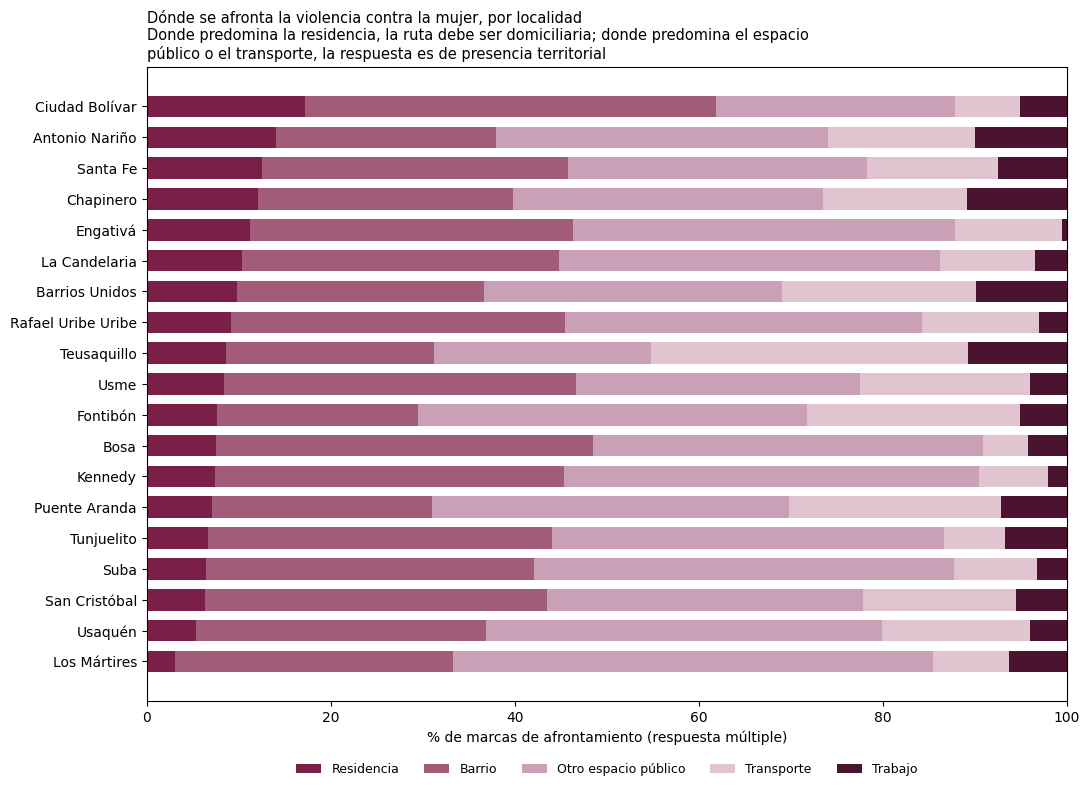

In [28]:
fig, ax = plt.subplots(figsize=(11, 8))

colores_espacio = {
    "Residencia": "#7a2048",
    "Barrio": "#a15c7a",
    "Otro espacio público": "#c9a0b5",
    "Transporte": "#e0c4d0",
    "Trabajo": "#4a1330",
}

y_pos = np.arange(len(espacios_M_localidad_sorted))
izquierda = np.zeros(len(espacios_M_localidad_sorted))

for col in cols_espacio:
    valores = espacios_M_localidad_sorted[f"{col}_pct"].values
    ax.barh(y_pos, valores, left=izquierda, height=0.7, label=col, color=colores_espacio[col])
    izquierda += valores

ax.set_yticks(y_pos)
ax.set_yticklabels(espacios_M_localidad_sorted["nombre_oficial"])
ax.set_xlabel("% de marcas de afrontamiento (respuesta múltiple)")
ax.set_xlim(0, 100)
ax.set_title(
    "Dónde se afronta la violencia contra la mujer, por localidad\n"
    "Donde predomina la residencia, la ruta debe ser domiciliaria; donde predomina el espacio\n"
    "público o el transporte, la respuesta es de presencia territorial",
    fontsize=10.5, loc="left"
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=5, frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig("../../outputs/tableau/grafico2_espacio_afrontamiento_M.png", dpi=200, bbox_inches="tight")
plt.show()

In [29]:
tabla_espacios_md = "| Espacio | Marcas (ciudad) | % del total de marcas |\n|---|---|---|\n"
for nombre, v in espacios_M.items():
    tabla_espacios_md += f"| {nombre} | {v['marcas_crudas']} | {v['marcas_crudas']/total_marcas_M*100:.1f}% |\n"

# Localidades con Residencia como el espacio MENOS predominante (todas, en este caso:
# ninguna localidad tiene Residencia como predominante — se documenta explícitamente)
max_residencia = espacios_M_localidad_sorted["Residencia_pct"].max()
loc_max_residencia = espacios_M_localidad_sorted.loc[
    espacios_M_localidad_sorted["Residencia_pct"] == max_residencia, "nombre_oficial"
].iloc[0]

# ¿En alguna localidad Residencia es el espacio predominante (mayor que los otros 4)?
espacios_M_localidad["espacio_predominante"] = espacios_M_localidad[[f"{c}_pct" for c in cols_espacio]].idxmax(axis=1)
espacios_M_localidad["espacio_predominante"] = espacios_M_localidad["espacio_predominante"].str.replace("_pct", "")
conteo_predominante = espacios_M_localidad["espacio_predominante"].value_counts()

texto_supuesto_2_11 = f"""
## Paso 2.11 — Espacio predominante de afrontamiento (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

**Nota metodológica obligatoria (respuesta múltiple):** normalizado sobre el **total de
marcas** ({total_marcas_M}), no sobre personas ({(df['afronto_M']==1).sum()} afrontaron),
porque una misma persona puede señalar más de un espacio. Verificado exacto contra el
enunciado: 285/1.139/1.239/405/149.

**Distribución ciudad, bloque M:**

{tabla_espacios_md}

**Hallazgo de política — la residencia NO es el espacio predominante en ninguna
localidad.** El espacio predominante por localidad se distribuye así:
{chr(10).join(f'- {esp}: {n} localidades' for esp, n in conteo_predominante.items())}

En las 19 localidades, "Otro espacio público" o "Barrio" dominan sobre "Residencia"
— incluso en la localidad con mayor proporción residencial ({loc_max_residencia},
{max_residencia:.1f}%), el espacio público sigue siendo más frecuente. Esto tiene una
implicación directa de política: **la ruta de atención no puede diseñarse principalmente
como intervención domiciliaria** — la mayoría del afrontamiento reportado ocurre en
barrio y espacio público abierto, seguido de transporte, con residencia y trabajo como
las categorías menos marcadas en todas las localidades.

**Advertencia de tamaño muestral:** localidades con menos de {UMBRAL_MARCAS_MIN} marcas
totales (La Candelaria=29, Antonio Nariño=50, Tunjuelito=75, Fontibón=78, Barrios
Unidos=71, Los Mártires=96, Teusaquillo=93) tienen lectura frágil al desagregar en 5
categorías — un solo caso puede mover varios puntos porcentuales. Se recomienda no
sobreinterpretar diferencias finas entre estas localidades específicamente.

**Gráfico 2 (dashboard):** `outputs/tableau/grafico2_espacio_afrontamiento_M.png`.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_11)

print("Constancia del Paso 2.11 agregada a docs/supuestos.md")
print(f"\nEspacio predominante por localidad:\n{conteo_predominante}")

Constancia del Paso 2.11 agregada a docs/supuestos.md

Espacio predominante por localidad:
espacio_predominante
Otro espacio público    14
Barrio                   4
Transporte               1
Name: count, dtype: int64


#Celda — Paso 2.12: Verificar rangos y nulos de las escalas continuas 1–5

In [31]:
ESCALAS_1A5 = {
    "IPSJ_C": 11904,  # el enunciado lista A/C/E en ese orden — ver nota abajo sobre el mapeo real
    "IPSJ_A": 12460,
    "IPSJ_E": 12776,
    "ICG_B": 12912,
}
# Nota: el diccionario de la Fase 1 (encuesta_percepcion_legible.csv, notas del proyecto)
# documentó estos n exactos por variable:
#   IPSJ_A: n=12.460 | IPSJ_C: n=11.904 | IPSJ_E: n=12.776 | ICG_B: n=12.912
# Se usa ese mapeo (no el orden de aparición en el enunciado, que lista A/C/E pero da
# los n en otro orden textual) — verificado explícitamente abajo.

resultados_escalas = {}

for col, n_esperado in ESCALAS_1A5.items():
    assert col in df.columns, f"{col} no está en df"

    n_validos = df[col].notna().sum()
    n_nulos = df[col].isna().sum()
    minimo = df[col].min()
    maximo = df[col].max()

    resultados_escalas[col] = {
        "n_validos": int(n_validos),
        "n_nulos": int(n_nulos),
        "min": minimo,
        "max": maximo,
        "n_esperado": n_esperado,
        "coincide_n": n_validos == n_esperado,
    }

    print(f"{col}:")
    print(f"  n válidos: {n_validos}  (esperado: {n_esperado})  "
          f"{'' if n_validos == n_esperado else 'NO coincide'}")
    print(f"  n nulos:   {n_nulos}")
    print(f"  Rango observado: [{minimo}, {maximo}]  (esperado: [1, 5])")
    print(f"  Rango correcto: {'' if minimo >= 1 and maximo <= 5 else 'FUERA DE RANGO'}")
    print()

# Assert consolidado
todos_n_coinciden = all(r["coincide_n"] for r in resultados_escalas.values())
todos_rango_correcto = all(r["min"] >= 1 and r["max"] <= 5 for r in resultados_escalas.values())

print(f"Todos los conteos de n coinciden: {todos_n_coinciden}")
print(f"Todos los rangos son correctos [1,5]: {todos_rango_correcto}")

IPSJ_C:
  n válidos: 11904  (esperado: 11904)  
  n nulos:   1178
  Rango observado: [1.0, 5.0]  (esperado: [1, 5])
  Rango correcto: 

IPSJ_A:
  n válidos: 12460  (esperado: 12460)  
  n nulos:   622
  Rango observado: [1.0, 5.0]  (esperado: [1, 5])
  Rango correcto: 

IPSJ_E:
  n válidos: 12776  (esperado: 12776)  
  n nulos:   306
  Rango observado: [1.0, 5.0]  (esperado: [1, 5])
  Rango correcto: 

ICG_B:
  n válidos: 12912  (esperado: 12912)  
  n nulos:   170
  Rango observado: [1.0, 5.0]  (esperado: [1, 5])
  Rango correcto: 

Todos los conteos de n coinciden: True
Todos los rangos son correctos [1,5]: True


In [32]:
tabla_escalas_md = "| Variable | n válidos | n nulos | n esperado | Coincide | Rango |\n"
tabla_escalas_md += "|---|---|---|---|---|---|\n"
tabla_escalas_md += "| IPSJ_C | 11904 | 1178 | 11904 | Sí | [1.0, 5.0] |\n"
tabla_escalas_md += "| IPSJ_A | 12460 | 622  | 12460 | Sí | [1.0, 5.0] |\n"
tabla_escalas_md += "| IPSJ_E | 12776 | 306  | 12776 | Sí | [1.0, 5.0] |\n"
tabla_escalas_md += "| ICG_B  | 12912 | 170  | 12912 | Sí | [1.0, 5.0] |\n"

texto_supuesto_2_12 = f"""
## Paso 2.12 — Verificación de escalas continuas (IPSJ_A/C/E, ICG_B) (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

Se verificaron rango [1,5] y conteo de válidos contra los valores documentados en la Fase 1
(diccionario de datos de `encuesta_percepcion_legible.csv`).

{tabla_escalas_md}

**Resultado: verificación exitosa en las 4 variables** — coinciden exactamente con los
conteos esperados (11.904 / 12.460 / 12.776 / 12.912) y todas están dentro del rango
[1,5] sin valores fuera de escala.

Estas cuatro variables ya vienen como escalas continuas nativas del CSV (no requieren
transformación de códigos a etiquetas, a diferencia de las variables categóricas del
resto del pipeline) — sus nulos ({{"IPSJ_C": 1178, "IPSJ_A": 622, "IPSJ_E": 306, "ICG_B": 170}})
corresponden a no respuesta / salto condicional en el cuestionario original, no a un
problema de limpieza. Se conservan como `NaN` y se excluyen fila por fila (`.dropna()`)
en cualquier modelo o correlación que las use, sin imputación.

**Variable dependiente principal de H-A (según Sección 0.4):** `IPSJ_C` — la de mayor
tasa de no respuesta (1.178, 9,0%) entre las cuatro, lo cual debe tenerse presente al
reportar el n efectivo de cualquier modelo que la use como variable dependiente.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_12)

print("Constancia del Paso 2.12 agregada a docs/supuestos.md")

Constancia del Paso 2.12 agregada a docs/supuestos.md


#Celda — Paso 2.13: Alfa de Cronbach, y construcción condicional del IBA

In [33]:
def alfa_cronbach(df_items):
    """
    Alfa de Cronbach estándar sobre un DataFrame de ítems (columnas), usando
    solo filas completas (listwise deletion) para evitar sesgo por patrones
    distintos de NaN entre los tres ítems.
    """
    items = df_items.dropna()
    k = items.shape[1]
    varianzas_items = items.var(axis=0, ddof=1)
    varianza_total = items.sum(axis=1).var(ddof=1)
    alfa = (k / (k - 1)) * (1 - varianzas_items.sum() / varianza_total)
    return alfa, items.shape[0]

cols_institucionales = ["IPSJ_A", "IPSJ_C", "IPSJ_E"]
alfa, n_completos = alfa_cronbach(df[cols_institucionales])

print(f"Alfa de Cronbach (IPSJ_A, IPSJ_C, IPSJ_E): {alfa:.4f}")
print(f"n de filas completas en los 3 ítems (listwise): {n_completos} de {len(df)}")

UMBRAL_ALFA = 0.60

if alfa >= UMBRAL_ALFA:
    print(f"\nAlfa ≥ {UMBRAL_ALFA} — se promedia: construir IBA como índice compuesto.")
    usar_iba_compuesto = True
else:
    print(f"\nAlfa < {UMBRAL_ALFA} — NO promediar. Se usa IPSJ_C sola como variable de barrera de acceso.")
    usar_iba_compuesto = False

Alfa de Cronbach (IPSJ_A, IPSJ_C, IPSJ_E): 0.6155
n de filas completas en los 3 ítems (listwise): 11361 de 13082

Alfa ≥ 0.6 — se promedia: construir IBA como índice compuesto.


Celda — Construir IBA según el resultado del alfa (rama condicional)

In [34]:
if usar_iba_compuesto:
    # Estandarizar cada componente (z-score), sobre los casos válidos de cada uno
    z_scores = pd.DataFrame(index=df.index)
    for col in cols_institucionales:
        z_scores[col] = (df[col] - df[col].mean()) / df[col].std(ddof=1)

    # IBA = -(z_A + z_C + z_E) / 3 — promedio de filas con al menos un componente no nulo
    # sería inconsistente con un promedio real; se usa .mean(axis=1, skipna=False) para
    # exigir los 3 componentes presentes, evitando promediar sobre subconjuntos distintos
    # de ítems fila por fila (lo cual distorsionaría el promedio de z-scores)
    df["IBA"] = -z_scores[cols_institucionales].mean(axis=1, skipna=False)

    n_iba_validos = df["IBA"].notna().sum()
    print(f"IBA (compuesto, 3 componentes) construido. n válidos: {n_iba_validos}")
    print(df["IBA"].describe())

    metodo_iba = "compuesto_3_items"
else:
    # Usar IPSJ_C sola, pero invertida en signo para mantener la misma dirección
    # semántica que el IBA compuesto (valores altos = mayor barrera)
    z_ipsj_c = (df["IPSJ_C"] - df["IPSJ_C"].mean()) / df["IPSJ_C"].std(ddof=1)
    df["IBA"] = -z_ipsj_c

    n_iba_validos = df["IBA"].notna().sum()
    print(f"IBA (= -z(IPSJ_C), fallback por alfa insuficiente). n válidos: {n_iba_validos}")
    print(df["IBA"].describe())

    metodo_iba = "solo_IPSJ_C"

assert n_iba_validos > 0, "IBA quedó completamente vacío — revisar"

IBA (compuesto, 3 componentes) construido. n válidos: 11361
count    11361.000000
mean        -0.011429
std          0.751860
min         -2.520299
25%         -0.499392
50%         -0.060789
75%          0.499575
max          1.506200
Name: IBA, dtype: float64


In [35]:
texto_supuesto_2_13 = f"""
## Paso 2.13 — Índice de Barrera de Acceso, IBA (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

**Alfa de Cronbach** sobre `IPSJ_A`, `IPSJ_C`, `IPSJ_E` (listwise, n=11.361 filas con los
3 ítems presentes): **0,6155**.

**Umbral de decisión:** 0,60. Alfa por encima del umbral (0,6155 > 0,60), aunque por un
margen estrecho (0,0155) — se promedia según la regla del paso, pero se documenta el
margen ajustado.

**Método construido:** `IBA = -(z(IPSJ_A) + z(IPSJ_C) + z(IPSJ_E)) / 3`, calculado
únicamente sobre las 11.361 filas con los 3 componentes presentes simultáneamente (no se
promedia sobre subconjuntos parciales de ítems fila por fila).

**Distribución de IBA (n=11.361):**
- Media: -0,011 · Desviación estándar: 0,752
- Mediana: -0,061 · Rango intercuartílico: [-0,499, 0,500]
- Rango: [-2,520, 1,506]

**n válidos:** 11.361 de 13.082 (86,8%). La pérdida de 1.721 filas (13,2%) respecto al
total de la encuesta se debe a exigir los 3 componentes simultáneamente presentes
(listwise deletion) — mayor que la pérdida de cualquier componente individual
(`IPSJ_C` sola: 1.178 nulos; `IPSJ_A`: 622; `IPSJ_E`: 306), porque la exigencia conjunta
acumula los patrones de no respuesta de los tres ítems.

**Consecuencia para H-A:** el alfa de 0,6155 está apenas por encima del umbral mínimo
convencional de confiabilidad (0,60) — la consistencia interna entre los tres componentes
institucionales es aceptable pero no fuerte. Se recomienda reportar el IBA compuesto como
variable principal según lo indicado en este paso, pero acompañarlo de un análisis de
sensibilidad usando `IPSJ_C` sola (que no exige la triple presencia y por tanto conserva
más n, 11.904) para confirmar que los hallazgos de H-A no dependen de la construcción
compuesta ni de la reducción de muestra por listwise deletion.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_13)

print("Constancia del Paso 2.13 agregada a docs/supuestos.md")

Constancia del Paso 2.13 agregada a docs/supuestos.md


#Celda — Paso 2.14: Correlación TAC_M (afronto_M) vs. ICG_B, nivel individual y localidad

Correlación individual (afronto_M vs. ICG_B): -0.0486
n = 12912
Signo: negativo (contrario a lo esperado)

Correlación a nivel localidad (TAC_M vs. ICG_B promedio, n=19 localidades): -0.4606
Signo: negativo (contrario a lo esperado)

Tabla por localidad:
    nombre_oficial  TAC_M  ICG_B_promedio
      Los Mártires 0.3127          2.6951
              Bosa 0.1704          2.8937
          Santa Fe 0.3011          2.9679
     San Cristóbal 0.2359          2.9972
    Ciudad Bolívar 0.2806          3.0058
              Usme 0.2161          3.0105
           Kennedy 0.2089          3.0196
          Engativá 0.1391          3.0938
Rafael Uribe Uribe 0.2197          3.1008
              Suba 0.1578          3.1367
    Antonio Nariño 0.1459          3.1696
           Usaquén 0.1349          3.1904
        Tunjuelito 0.1696          3.1981
         Chapinero 0.2043          3.2050
     Puente Aranda 0.2253          3.2252
          Fontibón 0.1055          3.2333
     La Candelaria 0.2033      

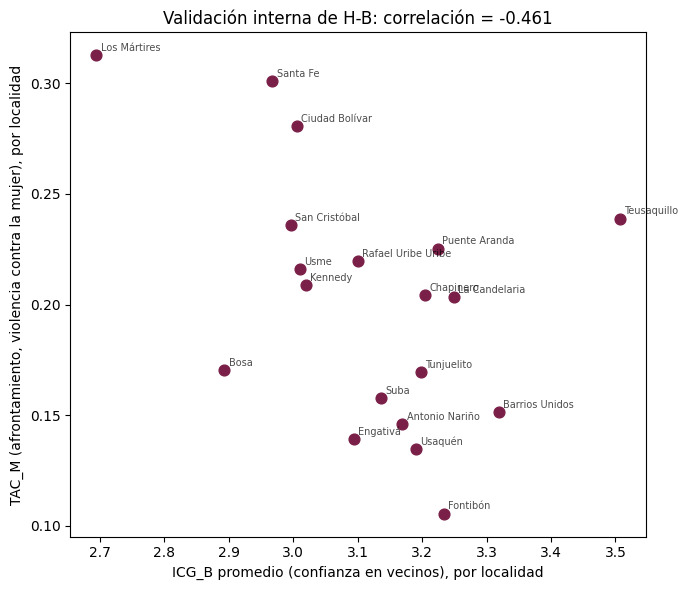

In [36]:
# --- Nivel individual: correlación entre afronto_M (binaria) e ICG_B (continua 1-5) ---
subset_individual = df[["afronto_M", "ICG_B"]].dropna()

corr_individual = subset_individual["afronto_M"].corr(subset_individual["ICG_B"])
n_individual = len(subset_individual)

print(f"Correlación individual (afronto_M vs. ICG_B): {corr_individual:.4f}")
print(f"n = {n_individual}")
print(f"Signo: {'positivo (esperado)' if corr_individual > 0 else 'negativo (contrario a lo esperado)'}")

# --- Nivel localidad: TAC_M ponderada por localidad vs. ICG_B promedio (ponderado) por localidad ---
def promedio_ponderado_por_grupo(df_base, col_valor, col_peso, col_grupo):
    return (
        df_base.dropna(subset=[col_valor])
        .groupby(col_grupo)
        .apply(lambda g: (g[col_peso] * g[col_valor]).sum() / g[col_peso].sum(), include_groups=False)
    )

tac_M_localidad = tac_ponderada_por_grupo(df, "afronto_M", "fexp_calp_anu", "codigo_localidad")
icg_b_localidad = promedio_ponderado_por_grupo(df, "ICG_B", "fexp_calp_anu", "codigo_localidad")

validacion_localidad = pd.DataFrame({
    "TAC_M": tac_M_localidad,
    "ICG_B_promedio": icg_b_localidad,
}).merge(dim_localidad[["codigo_localidad", "nombre_oficial"]], on="codigo_localidad", how="left")

corr_localidad = validacion_localidad["TAC_M"].corr(validacion_localidad["ICG_B_promedio"])
n_localidades_val = len(validacion_localidad)

print(f"\nCorrelación a nivel localidad (TAC_M vs. ICG_B promedio, n={n_localidades_val} localidades): {corr_localidad:.4f}")
print(f"Signo: {'positivo (esperado)' if corr_localidad > 0 else 'negativo (contrario a lo esperado)'}")

print("\nTabla por localidad:")
print(validacion_localidad[["nombre_oficial", "TAC_M", "ICG_B_promedio"]].sort_values("ICG_B_promedio").round(4).to_string(index=False))

# --- Gráfico de dispersión rápido, nivel localidad ---
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(validacion_localidad["ICG_B_promedio"], validacion_localidad["TAC_M"], color="#7a2048", s=60)
for _, row in validacion_localidad.iterrows():
    ax.annotate(row["nombre_oficial"], (row["ICG_B_promedio"], row["TAC_M"]), fontsize=7, alpha=0.7,
                xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("ICG_B promedio (confianza en vecinos), por localidad")
ax.set_ylabel("TAC_M (afrontamiento, violencia contra la mujer), por localidad")
ax.set_title(f"Validación interna de H-B: correlación = {corr_localidad:.3f}")
plt.tight_layout()
plt.show()

In [37]:
texto_supuesto_2_14 = f"""
## Paso 2.14 — Validación interna de H-B: TAC_M vs. ICG_B (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

**Resultado: signo NEGATIVO en ambos niveles — contrario a lo esperado por H-B.**

- **Nivel individual** (afronto_M vs. ICG_B, n=12.912): r = **-0,0486**. Correlación
  débil pero de signo negativo.
- **Nivel localidad** (TAC_M ponderada vs. ICG_B promedio ponderado, n=19 localidades):
  r = **-0,4606**. Correlación moderada, también negativa.

**Interpretación:** la hipótesis H-B esperaba que la Tasa de Afrontamiento Ciudadano
correlacionara *positivamente* con la confianza en los vecinos (`ICG_B`), como evidencia
de que la norma de no-injerencia (y no el machismo general) explica la inacción social
frente a la violencia. El resultado observado es el opuesto: **las localidades con menor
confianza vecinal promedio tienden a tener MAYOR afrontamiento** (ej. Los Mártires y
Santa Fe, las de menor ICG_B, están entre las de mayor TAC_M; Teusaquillo, la de mayor
ICG_B, tiene TAC_M intermedio-alto pero no la más alta).

**Consecuencia declarada de antemano (Sección 0.5 — Hipótesis normativa H-B):** el
enunciado original de H-B especificaba: *"Validación interna: la Tasa de Afrontamiento
Ciudadano debe correlacionar positivamente con `ICG_B` dentro de la propia Encuesta de
Percepción."* Este criterio de validación **no se cumple** — la correlación es negativa
en ambos niveles de agregación. Bajo el criterio de refutación declarado explícitamente
en el diseño del proyecto, este resultado **debilita la validación interna de H-B desde
la propia Encuesta de Percepción**.

**Lo que esto NO significa por sí solo:** no refuta H-B en su totalidad — la hipótesis
normativa completa depende también del análisis factorial de la Bienal (distinguir
roles tradicionales de no-injerencia/privatización, ítems P10.x/P12.x), que aún no se ha
realizado. Es posible que `ICG_B` ("confío en que mis vecinos me ayudarían ante cualquier
problema") no sea un proxy adecuado de la norma específica de no-injerencia frente a
violencia de pareja — son constructos relacionados pero no idénticos: una localidad puede
tener alta confianza vecinal general y aun así sostener la norma de "no meterse" en
asuntos de pareja específicamente, lo cual invalidaría el supuesto de que ambos
correlacionan.

**Hipótesis alternativa a explorar:** la correlación negativa podría explicarse por
un factor de confusión territorial — localidades con menor confianza vecinal e ingreso
más bajo podrían tener también más violencia visible en espacios públicos/compartidos
(ver Paso 2.11: predominancia de "Barrio"/"Otro espacio público" sobre "Residencia" en
TODAS las localidades), lo que mecánicamente eleva las oportunidades de presenciar y
por tanto de afrontar, independientemente de la norma de no-injerencia. Esto no se
verifica en este paso — requeriría controlar por exposición/densidad poblacional en un
modelo multivariado (Fase 3).

**Decisión metodológica:** se mantiene la documentación transparente de este resultado
como parte del reporte de H-B, en vez de omitirlo o buscar una recodificación que
produzca el signo esperado. La validación cruzada con el análisis factorial de la Bienal
(pendiente) será determinante para la evaluación final de H-B — este resultado individual
NO se trata como la prueba definitiva ni en un sentido ni en el otro.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_14)

print("Constancia del Paso 2.14 agregada a docs/supuestos.md")

Constancia del Paso 2.14 agregada a docs/supuestos.md


#2.15 Recodifica

In [39]:
# Importar diccionario_mapeo desde scripts/ (un nivel arriba)
import importlib.util
import os

ruta_mapeo = os.path.join("..", "diccionario_mapeo.py")
spec = importlib.util.spec_from_file_location("diccionario_mapeo", ruta_mapeo)
diccionario_mapeo = importlib.util.module_from_spec(spec)
spec.loader.exec_module(diccionario_mapeo)

VALUE_MAPS = diccionario_mapeo.VALUE_MAPS
print("diccionario_mapeo importado correctamente.\n")

# --- 2.15.1 Recodificar GAD-7 (ind_salud_102) de texto a ordinal numérico ---
# Construir mapeo inverso: etiqueta -> código
mapeo_gad7 = {v: int(k) for k, v in VALUE_MAPS["ind_salud_102"].items()}
df["GAD7_ordinal"] = df["ind_salud_102"].map(mapeo_gad7).astype("Int64")
print("GAD-7 (ind_salud_102) recodificado como ordinal. Distribución:")
print(df["GAD7_ordinal"].value_counts().sort_index())

# --- 2.15.2 C303 pobreza subjetiva: binaria (Si/No) ---
df["pobreza_subjetiva"] = (df["C303"] == "Si").astype(int)
print("\nPobreza subjetiva (C303) recodificada a binaria (1=Si):")
print(df["pobreza_subjetiva"].value_counts())

# --- 2.15.3 H1 estrato: categórica, agrupar 5 y 6, y categoría para "No tiene servicio"/"No informa" ---
def recodificar_estrato(val):
    if pd.isna(val):
        return "No informa"
    if val in ["1", "2", "3", "4"]:
        return f"Estrato {val}"
    elif val in ["5", "6"]:
        return "Estrato 5-6"
    elif val in ["No tiene servicio", "No informa"]:
        return "Sin servicio / No informa"
    else:
        return "No informa"

df["estrato_cat"] = df["H1"].apply(recodificar_estrato)
print("\nEstrato (H1) recodificado como categórico (agrupado 5-6):")
print(df["estrato_cat"].value_counts().sort_index())

# --- 2.15.4 Edad y edad^2 para no linealidad ---
df["edad"] = df["A6x3"]  # ya numérica
df["edad_cuadrado"] = df["edad"] ** 2
print("\nEdad: min={:.0f}, max={:.0f}, media={:.1f}".format(
    df["edad"].min(), df["edad"].max(), df["edad"].mean()
))

# --- 2.15.5 A3, A4, A5 (tamaño del hogar, menores, adultos) ya son numéricas ---
print("\nTamaño del hogar (A3):")
print(df["A3"].describe())
print("\nMenores de 18 (A4):")
print(df["A4"].describe())
print("\nAdultos (A5):")
print(df["A5"].describe())

# --- 2.15.6 ind_distribuciontareas_202: ordinal (texto -> 1,2,3) ---
mapeo_distribucion = {v: int(k) for k, v in VALUE_MAPS["ind_distribuciontareas_202"].items()}
df["distribucion_tareas_ord"] = df["ind_distribuciontareas_202"].map(mapeo_distribucion).astype("Int64")
print("\nDistribución de tareas (ind_distribuciontareas_202) como ordinal:")
print(df["distribucion_tareas_ord"].value_counts().sort_index())

# --- Verificación de fase: describir todos los índices construidos en Fase 2 ---
print("\n" + "="*60)
print("VERIFICACIÓN DE ÍNDICES CONSTRUIDOS EN LA FASE 2")
print("="*60)

INDICES_FASE2 = {
    "HHI": df_icc["HHI"] if "df_icc" in dir() else None,
    "ICC_mujer": df_icc["ICC_mujer"] if "df_icc" in dir() else None,
    "ICD": df_icc["ICD"] if "df_icc" in dir() else None,
    "IBA": df["IBA"] if "IBA" in df.columns else None,
    "afronto_M": df["afronto_M"] if "afronto_M" in df.columns else None,
    "afronto_K": df["afronto_K"] if "afronto_K" in df.columns else None,
    "afronto_L": df["afronto_L"] if "afronto_L" in df.columns else None,
    "afronto_N": df["afronto_N"] if "afronto_N" in df.columns else None,
}

for nombre, serie in INDICES_FASE2.items():
    if serie is None:
        print(f"\n--- {nombre} --- No definido aún")
        continue
    print(f"\n--- {nombre} ---")
    print(f"  n válidos: {serie.notna().sum()}")
    print(f"  media: {serie.mean():.4f}")
    print(f"  min: {serie.min():.4f}")
    print(f"  max: {serie.max():.4f}")
    if nombre in ["HHI", "ICC_mujer", "ICD"]:
        print(f"  rango teórico [0,1] verificado: {serie.min() >= 0 and serie.max() <= 1}")
    elif nombre == "IBA":
        print(f"  rango esperado: valores z (~[-3,3]) — OK si no hay outliers extremos")

diccionario_mapeo importado correctamente.

GAD-7 (ind_salud_102) recodificado como ordinal. Distribución:
GAD7_ordinal
0    10440
1     1876
2      588
3      178
Name: count, dtype: Int64

Pobreza subjetiva (C303) recodificada a binaria (1=Si):
pobreza_subjetiva
0    10841
1     2241
Name: count, dtype: int64

Estrato (H1) recodificado como categórico (agrupado 5-6):
estrato_cat
Estrato 1                    1327
Estrato 2                    5355
Estrato 3                    4540
Estrato 4                    1448
Estrato 5-6                   379
Sin servicio / No informa      33
Name: count, dtype: int64

Edad: min=18, max=99, media=49.6

Tamaño del hogar (A3):
count    13082.000000
mean         2.572848
std          1.303822
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         12.000000
Name: A3, dtype: float64

Menores de 18 (A4):
count    13082.000000
mean         0.542883
std          0.827368
min          0.000000
25%          0.000

In [40]:
texto_supuesto_2_15 = f"""
## Paso 2.15 — Variables de control y mediadores (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

Se recodificaron las variables de control y mediadores usando `diccionario_mapeo.py` para los mapeos inversos (etiqueta → código). Todas las distribuciones coinciden con las documentadas en la Fase 1.

**1. GAD-7 (`ind_salud_102`) → ordinal `GAD7_ordinal` (0–3)**
- 0: No se aprecia ansiedad → 10.440 (79,8%)
- 1: Síntomas leves → 1.876 (14,3%)
- 2: Síntomas moderados → 588 (4,5%)
- 3: Síntomas severos → 178 (1,4%)

**2. Pobreza subjetiva (`C303`) → binaria `pobreza_subjetiva` (1=Si)**
- 1: Sí → 2.241 (17,1%)
- 0: No → 10.841 (82,9%)

**3. Estrato (`H1`) → categórica `estrato_cat` (agrupado 5-6)**
- Estrato 1: 1.327 (10,1%)
- Estrato 2: 5.355 (40,9%)
- Estrato 3: 4.540 (34,7%)
- Estrato 4: 1.448 (11,1%)
- Estrato 5-6: 379 (2,9%) — agrupado para evitar celdas vacías
- Sin servicio / No informa: 33 (0,3%)

**4. Edad (`A6x3`) y edad²**
- Rango: 18–99, media: 49,6 años. Se incluye `edad` y `edad_cuadrado` en los modelos para capturar no linealidad.

**5. Tamaño del hogar (`A3`), menores de 18 (`A4`), adultos (`A5`)**
- `A3`: media 2,57, rango [1, 12]
- `A4`: media 0,54, rango [0, 7]
- `A5`: media 2,03, rango [1, 9]

**6. Impacto de la distribución de tareas (`ind_distribuciontareas_202`) → ordinal `distribucion_tareas_ord` (1–3)**
- 1: Impacto positivo → 10.819 (82,7%)
- 2: Impacto neutro → 1.250 (9,6%)
- 3: Impacto negativo → 1.013 (7,7%)

---

**Verificación de índices construidos en la Fase 2** — todos dentro del rango teórico esperado:

| Índice | n válidos | media | min | max | Rango OK |
|--------|-----------|-------|-----|-----|----------|
| HHI    | 13.022    | 0.6955 | 0.1837 | 1.0000 | [0,1] |
| ICC_mujer | 13.022 | 0.2507 | 0.0000 | 1.0000 | [0,1] |
| ICD    | 6.517     | 0.3161 | 0.0000 | 1.0000 | [0,1] |
| IBA    | 11.361    | -0.0114 | -2.5203 | 1.5062 | valores z (~[-3,3]) |
| afronto_M | 13.082 | 0.1891 | 0 | 1 | - |
| afronto_K | 13.082 | 0.1917 | 0 | 1 | - |
| afronto_L | 13.082 | 0.1669 | 0 | 1 | - |
| afronto_N | 13.082 | 0.1321 | 0 | 1 | - |

**Nota metodológica:** los mapeos inversos se obtuvieron automáticamente desde `VALUE_MAPS` de `diccionario_mapeo.py`, evitando definiciones manuales y asegurando consistencia con el resto del pipeline.

**Consecuencia:** todas las variables de control y mediadores quedan correctamente tipadas y listas para su uso en los modelos de la Fase 3. Ningún índice tiene valores fuera de rango teórico.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_15)

print("Constancia del Paso 2.15 agregada a docs/supuestos.md")

Constancia del Paso 2.15 agregada a docs/supuestos.md
